# Industry DSR Impact Analysis

**Apples-to-apples comparison** of two model runs with identical temporal industrial demand profiles:

- **Reference**: Temporal industrial demand, NO DSR (`EU_test_run_temporal_no_dsr`)
- **DSR v3**: Temporal industrial demand + Industry DSR (`EU_test_run_dsr_v3_optional`)

Both runs use: 33 EU countries, 38 clusters, 2030 horizon, full year 2019 (2h resolution).

**Key metrics**: System cost, electricity prices, generation capacity, renewable curtailment, DSR utilization.

In [2]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# If you run this from /home/aceccato/work/pypsa-eurelectric:
print('Loading Reference (low-flex 2040)...')
n_ref = pypsa.Network(
    'results/2026-02/lowflex-2040-solar-cap-H2net-bio/networks/base_s_37___2040.nc'
)

print('Loading DSR scenario (high-flex 2040)...')
n_dsr = pypsa.Network(
    'results/2027-04-03/flex-2040-solar-cap-H2net-bio/networks/base_s_37___2040.nc'
)

print('Done.')

Loading Reference (low-flex 2040)...


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


Loading DSR scenario (high-flex 2040)...


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


Done.


## 0. Flat vs Temporal Industry Demand Profile

Before comparing the two DSR scenarios, let's visualize what "temporal industrial demand" means.
The original baseline uses a **flat** (constant) industry electricity demand, while the temporal runs
use hourly FfE load profiles that capture real production patterns (shift work, weekday/weekend, seasonal).

Loading flat baseline from: /home/aceccato/work/pypsa-eurelectric/results/EU_test_run/networks/base_s_38___2030.nc


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, stores, sub_networks


Done.

--- DE0 0 industry electricity ---
Flat demand:     28570 MW (constant, every hour)
Temporal demand: min=3431, max=8598, mean=6163 MW
Total flat:      124.79 TWh/year
Total temporal:  18.00 TWh/year


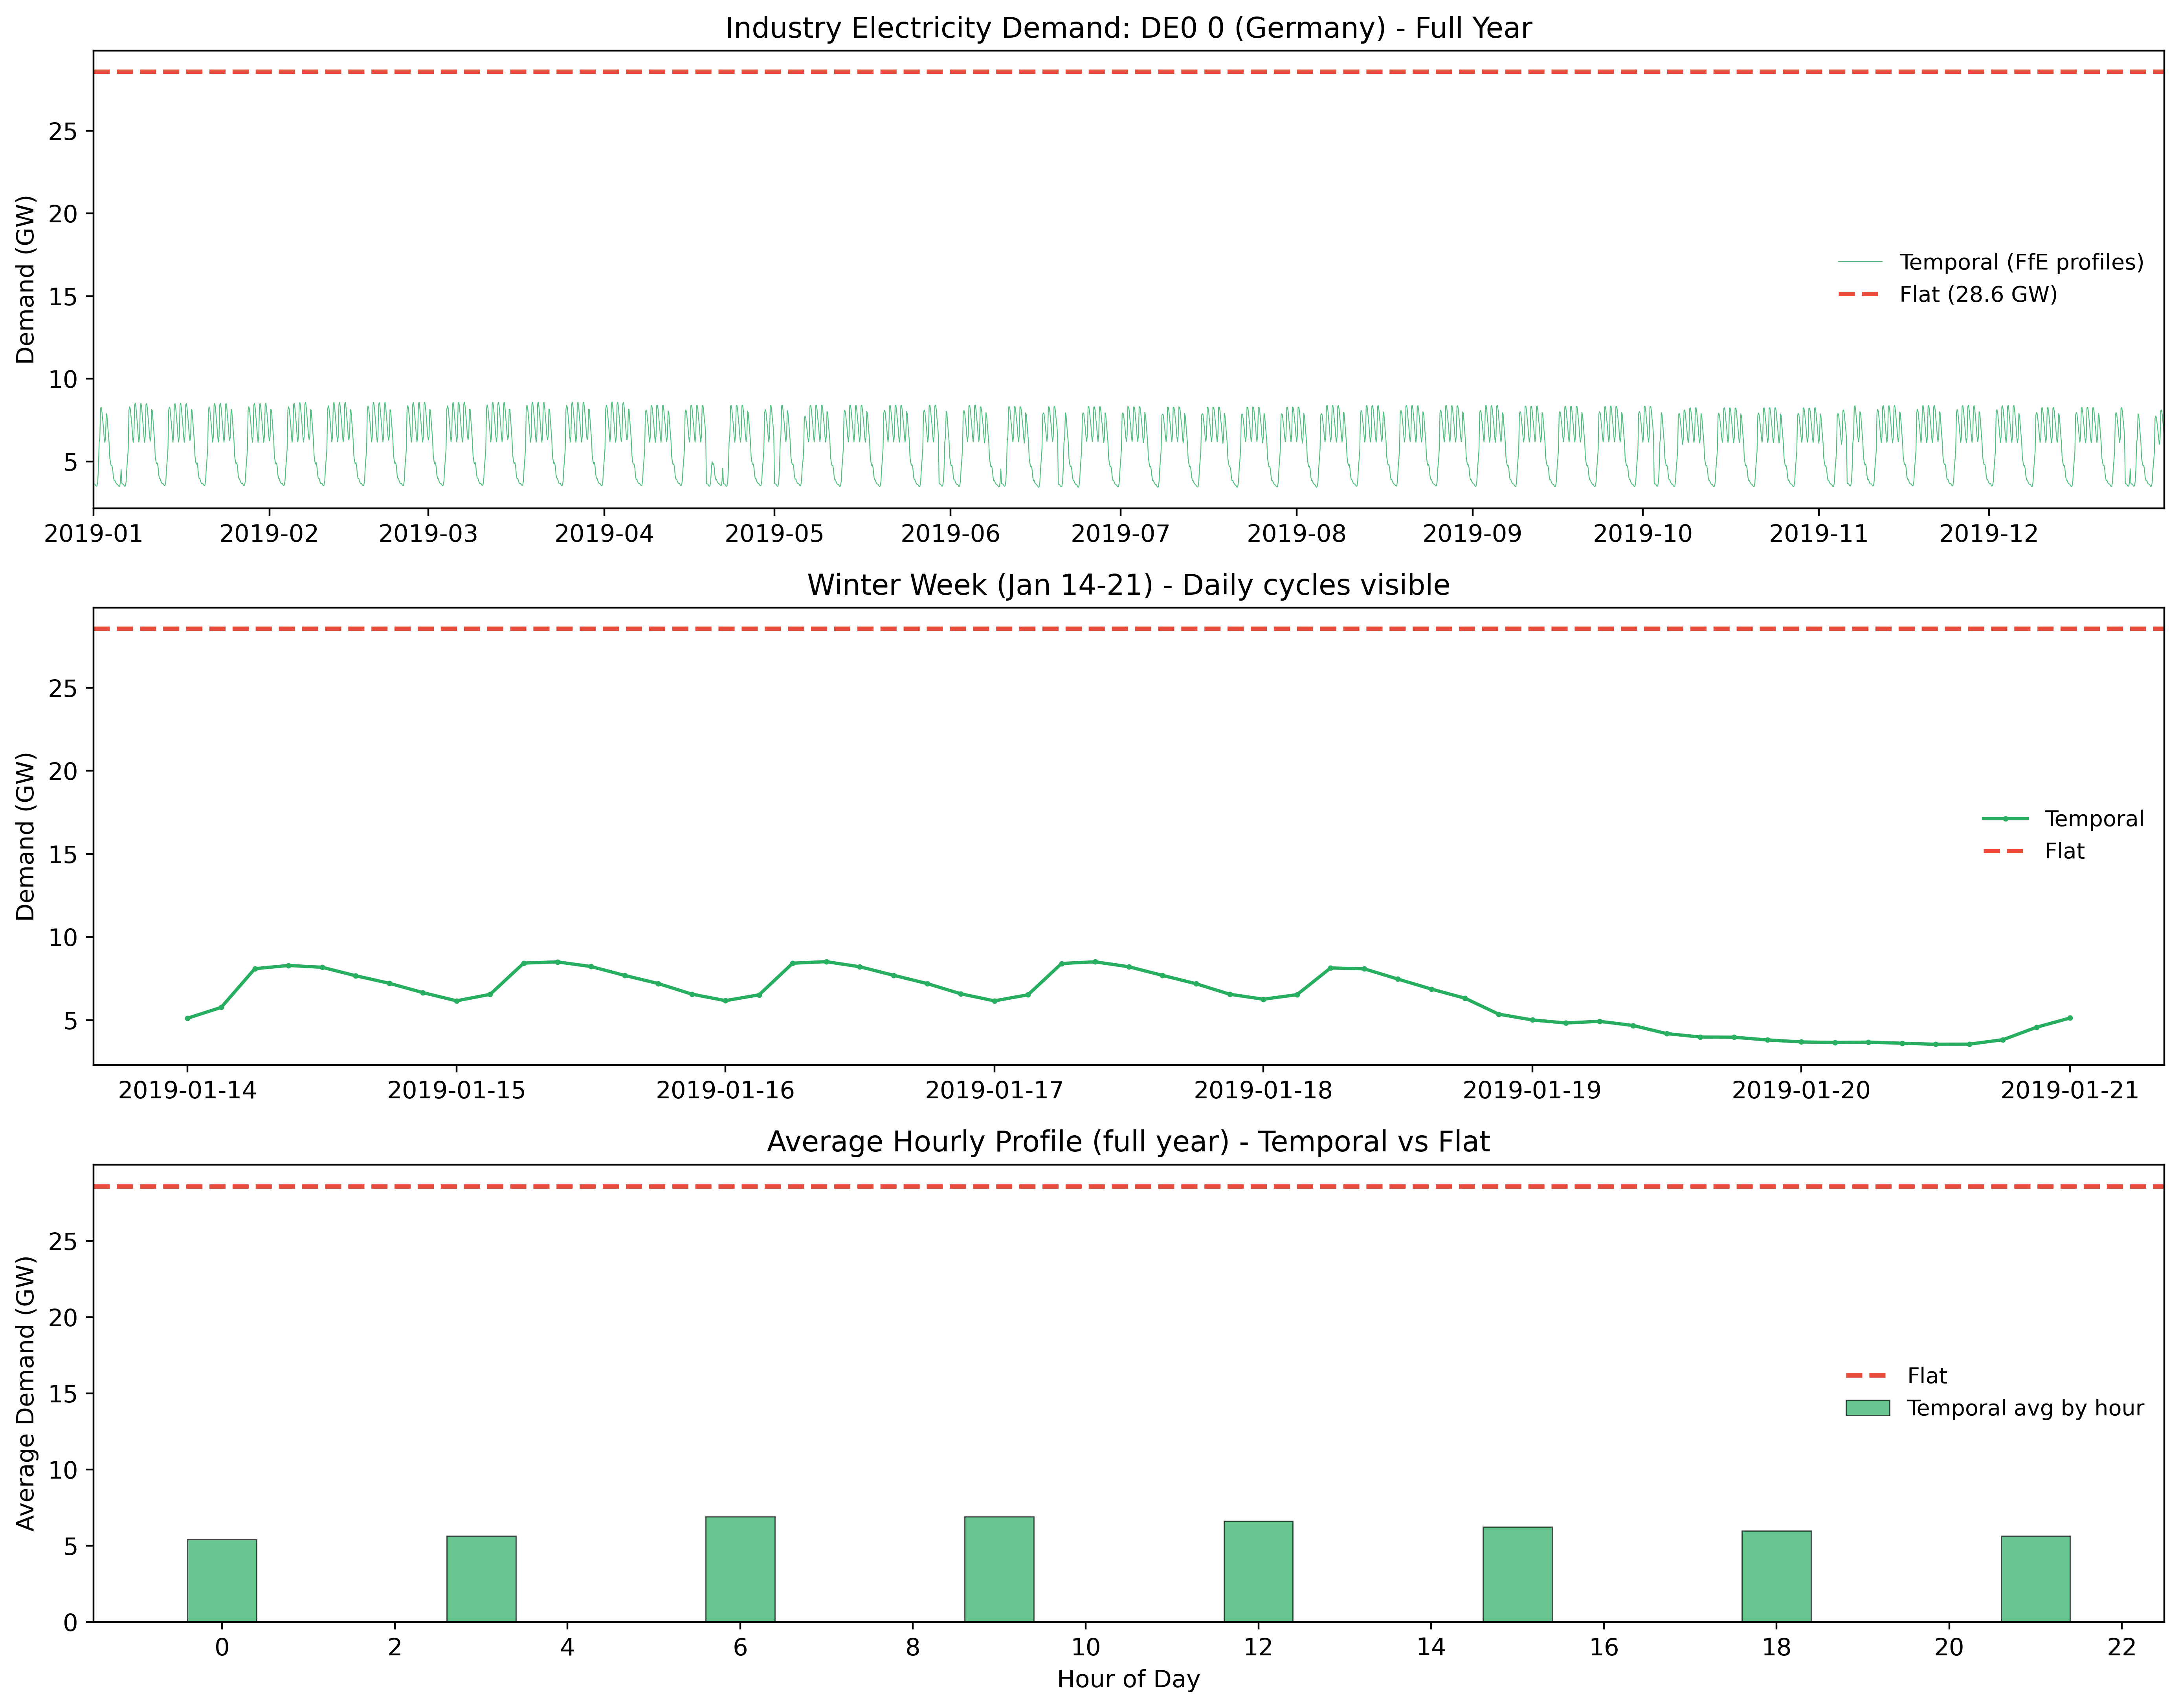


Key insight: The temporal profile has 18% peak-to-trough variation.
This intra-day variation is what creates the arbitrage opportunity for DSR.


In [3]:
# Load the original flat-demand baseline network
import os
flat_path = os.path.expanduser('~/work/pypsa-eurelectric/results/EU_test_run/networks/base_s_38___2030.nc')
print(f'Loading flat baseline from: {flat_path}')
n_flat = pypsa.Network(flat_path)
print('Done.')

# Pick Germany (DE0 0) as example - largest industrial node
node = 'DE0 0'
load_name = f'{node} industry electricity'

# Flat baseline: constant p_set (no time series)
flat_value = n_flat.loads.loc[load_name, 'p_set']  # MW, constant
flat_ts = pd.Series(flat_value, index=n_ref.snapshots)

# Temporal profile from the reference run (temporal, no DSR)
temporal_ts = n_ref.loads_t.p_set[load_name]

print(f'\n--- {load_name} ---')
print(f'Flat demand:     {flat_value:.0f} MW (constant, every hour)')
print(f'Temporal demand: min={temporal_ts.min():.0f}, max={temporal_ts.max():.0f}, mean={temporal_ts.mean():.0f} MW')
print(f'Total flat:      {flat_value * len(n_flat.snapshots) / 1e6:.2f} TWh/year')
print(f'Total temporal:  {temporal_ts.sum() / 1e6:.2f} TWh/year')

# ---- PLOT 1: Full year comparison ----
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# (a) Full year overlay
ax = axes[0]
ax.plot(temporal_ts.index, temporal_ts.values / 1e3, color='#27ae60', linewidth=0.4, alpha=0.8, label='Temporal (FfE profiles)')
ax.axhline(flat_value / 1e3, color='#e74c3c', linewidth=2, linestyle='--', label=f'Flat ({flat_value/1e3:.1f} GW)')
ax.set_ylabel('Demand (GW)')
ax.set_title(f'Industry Electricity Demand: {node} (Germany) - Full Year')
ax.legend(fontsize=10)
ax.set_xlim(temporal_ts.index[0], temporal_ts.index[-1])

# (b) One week zoom (January)
ax = axes[1]
week_start = pd.Timestamp('2019-01-14')
week_end = pd.Timestamp('2019-01-21')
temp_week = temporal_ts[week_start:week_end]
ax.plot(temp_week.index, temp_week.values / 1e3, color='#27ae60', linewidth=1.5, marker='.', markersize=3, label='Temporal')
ax.axhline(flat_value / 1e3, color='#e74c3c', linewidth=2, linestyle='--', label='Flat')
ax.set_ylabel('Demand (GW)')
ax.set_title(f'Winter Week (Jan 14-21) - Daily cycles visible')
ax.legend(fontsize=10)

# (c) Average hourly profile
ax = axes[2]
hourly_avg = temporal_ts.groupby(temporal_ts.index.hour).mean() / 1e3
ax.bar(hourly_avg.index, hourly_avg.values, color='#27ae60', alpha=0.7, edgecolor='black', linewidth=0.5, label='Temporal avg by hour')
ax.axhline(flat_value / 1e3, color='#e74c3c', linewidth=2, linestyle='--', label='Flat')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Demand (GW)')
ax.set_title('Average Hourly Profile (full year) - Temporal vs Flat')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nKey insight: The temporal profile has {(temporal_ts.max()-temporal_ts.min())/flat_value*100:.0f}% peak-to-trough variation.')
print('This intra-day variation is what creates the arbitrage opportunity for DSR.')

## 1. System Cost (Objective Value)

Reference (no DSR): 614.89 billion EUR
DSR v3:             592.37 billion EUR
DSR impact:         -22.52 billion EUR (-3.66%)


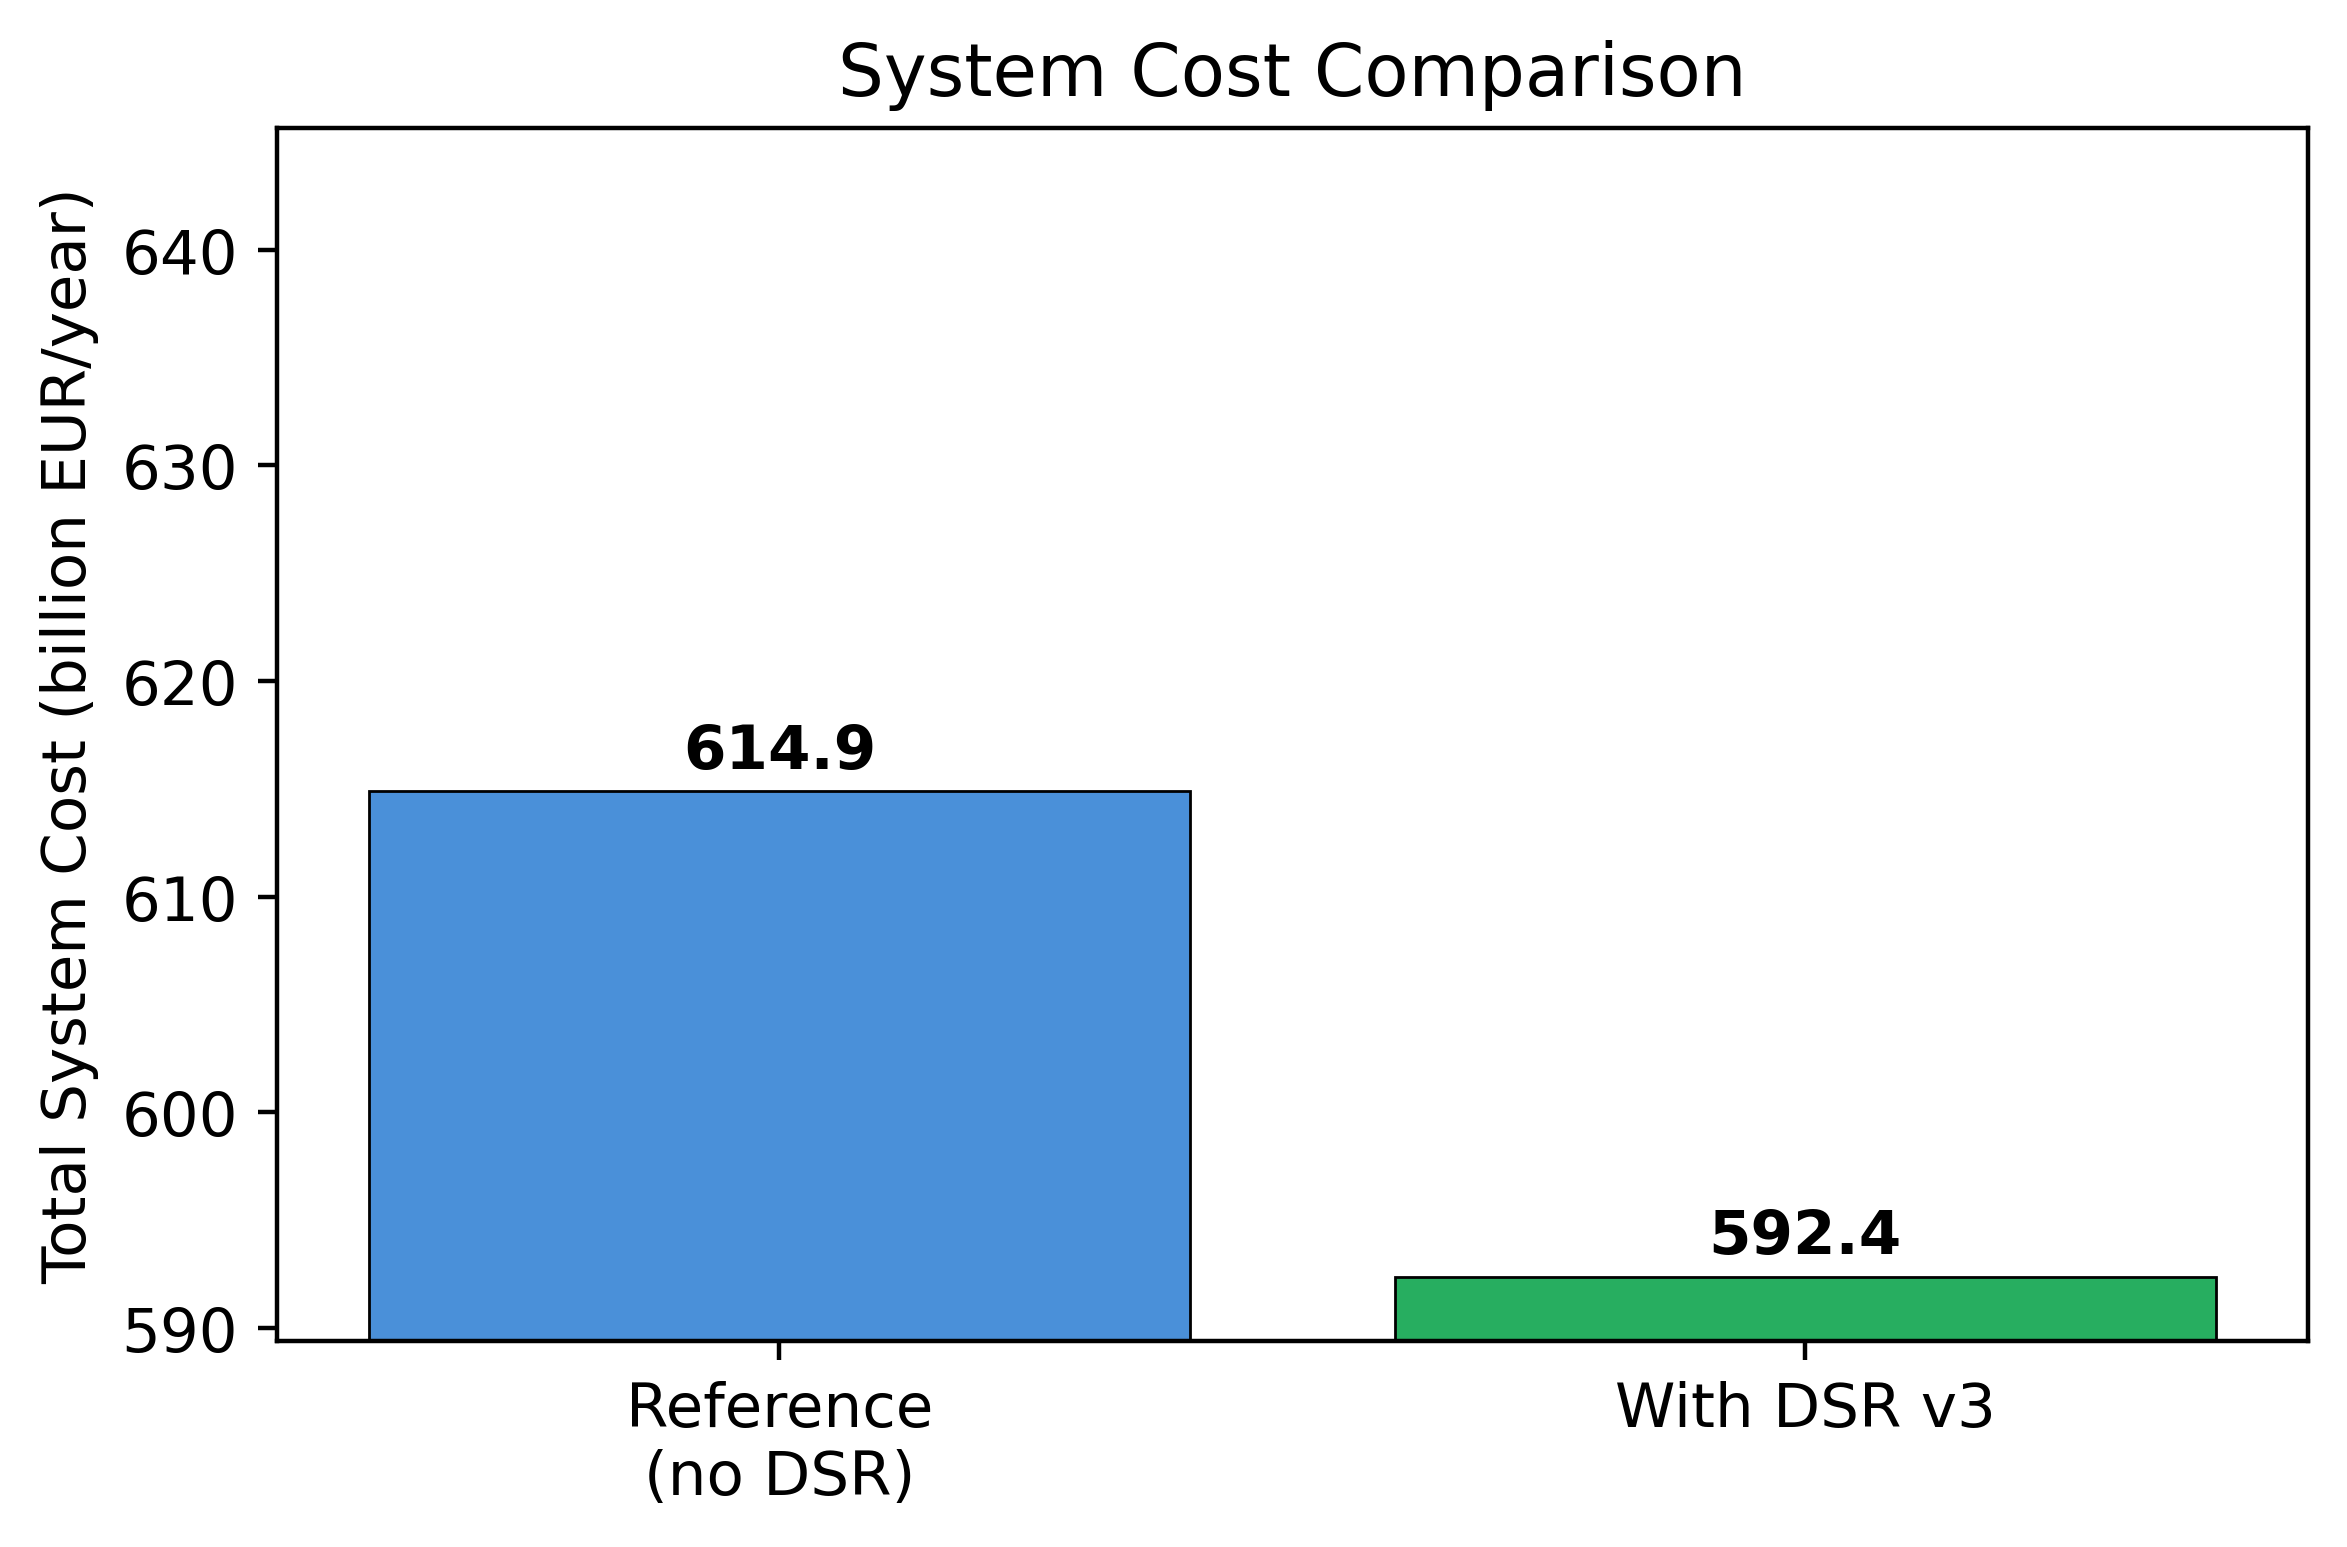

In [4]:
obj_ref = n_ref.objective
obj_dsr = n_dsr.objective
diff = obj_dsr - obj_ref
diff_pct = diff / obj_ref * 100

print(f'Reference (no DSR): {obj_ref/1e9:.2f} billion EUR')
print(f'DSR v3:             {obj_dsr/1e9:.2f} billion EUR')
print(f'DSR impact:         {diff/1e9:+.2f} billion EUR ({diff_pct:+.2f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Reference\n(no DSR)', 'With DSR v3'], [obj_ref/1e9, obj_dsr/1e9],
              color=['#4a90d9', '#27ae60'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Total System Cost (billion EUR/year)')
ax.set_title('System Cost Comparison')
for bar, val in zip(bars, [obj_ref/1e9, obj_dsr/1e9]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(bottom=min(obj_ref, obj_dsr)/1e9 * 0.995)
plt.tight_layout()
plt.show()

## 2. Electricity Prices

Average LV price (Reference): 102.56 EUR/MWh
Average LV price (DSR v3):    99.83 EUR/MWh
DSR impact: -2.66%


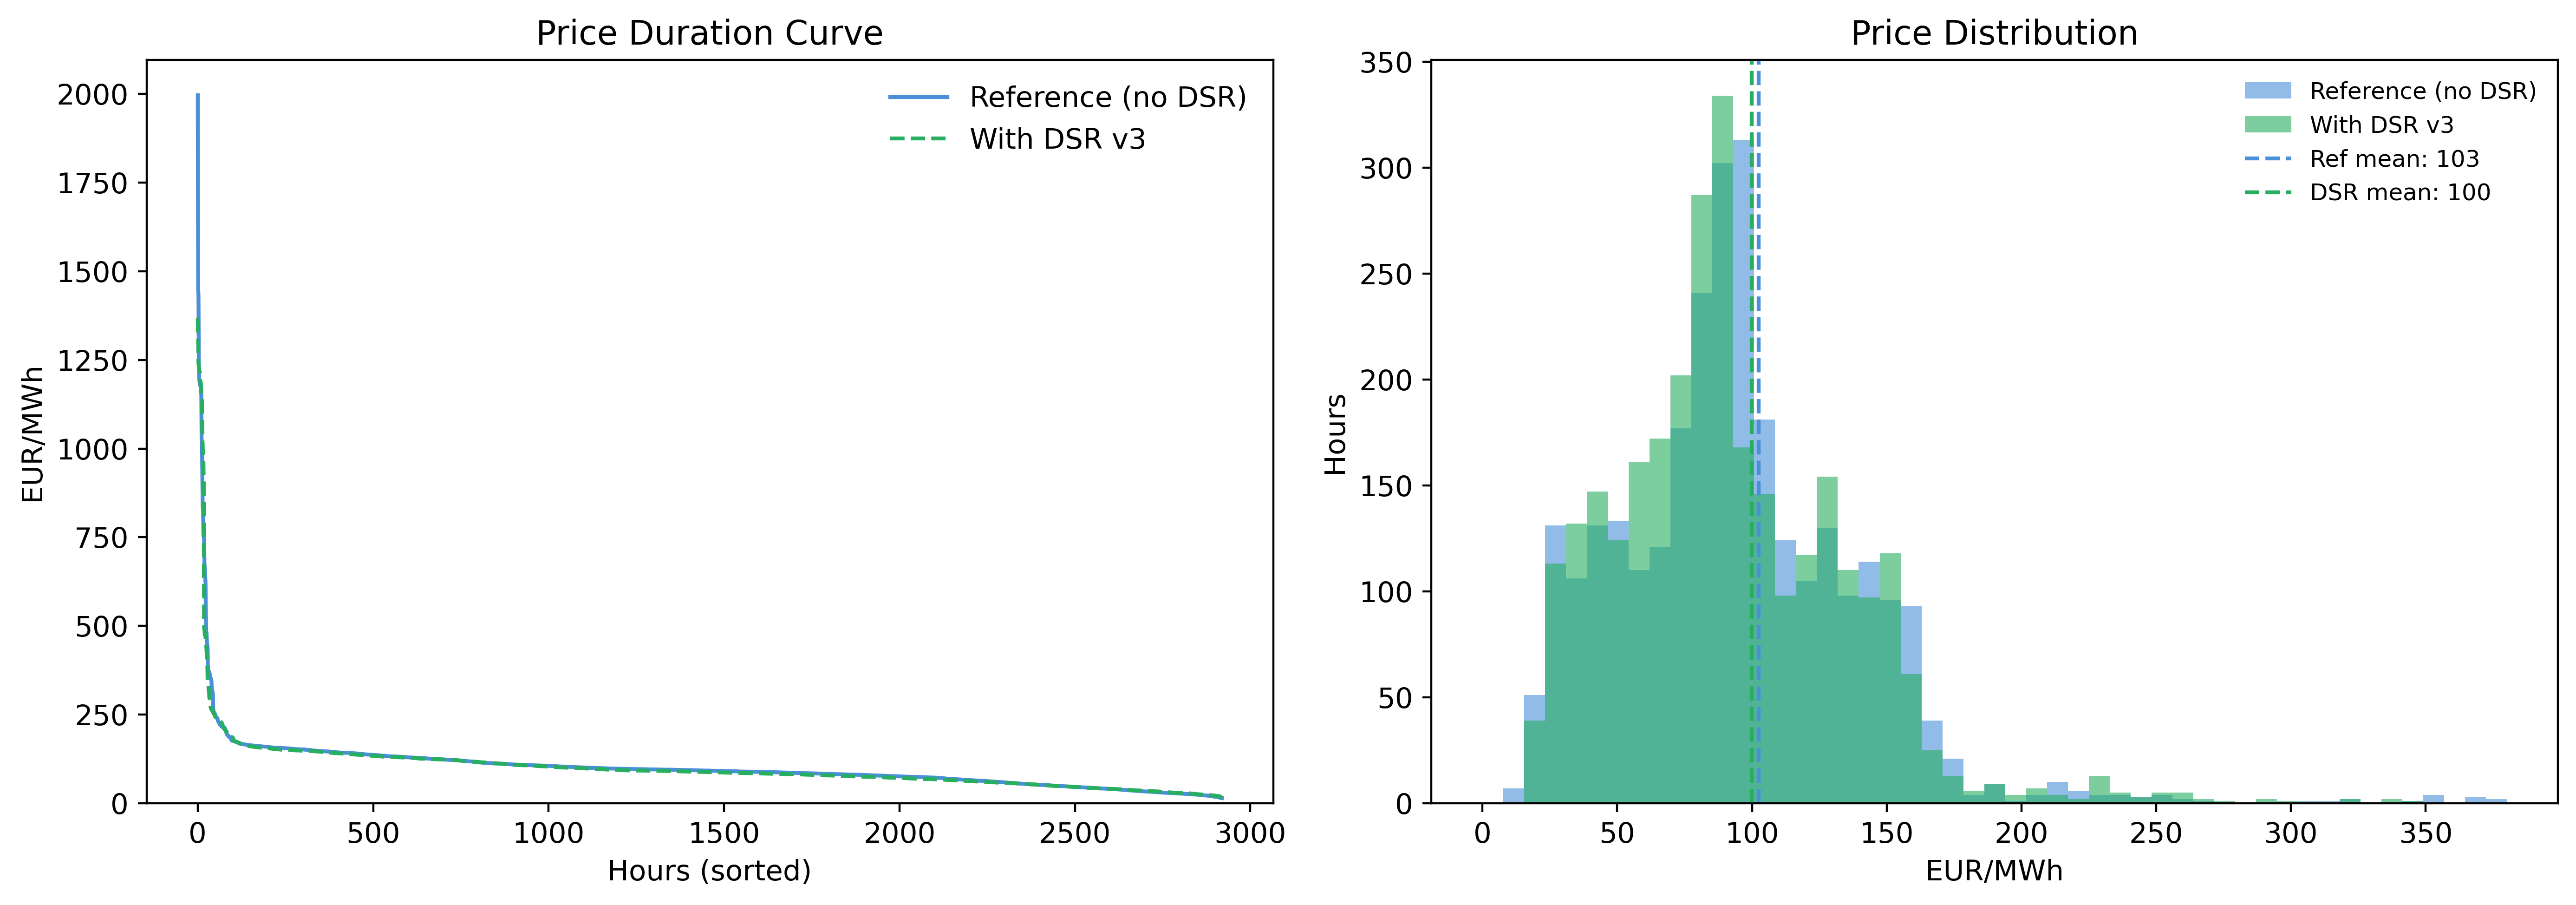

In [5]:
# Get low voltage bus prices
lv_ref = [b for b in n_ref.buses.index if 'low voltage' in b]
lv_dsr = [b for b in n_dsr.buses.index if 'low voltage' in b]

prices_ref = n_ref.buses_t.marginal_price[lv_ref]
prices_dsr = n_dsr.buses_t.marginal_price[lv_dsr]

avg_ref = prices_ref.mean().mean()
avg_dsr = prices_dsr.mean().mean()
print(f'Average LV price (Reference): {avg_ref:.2f} EUR/MWh')
print(f'Average LV price (DSR v3):    {avg_dsr:.2f} EUR/MWh')
print(f'DSR impact: {(avg_dsr-avg_ref)/avg_ref*100:+.2f}%')

# System-wide hourly average price
hourly_ref = prices_ref.mean(axis=1)
hourly_dsr = prices_dsr.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price duration curve
ax = axes[0]
sorted_ref = hourly_ref.sort_values(ascending=False).reset_index(drop=True)
sorted_dsr = hourly_dsr.sort_values(ascending=False).reset_index(drop=True)
ax.plot(sorted_ref.values, label='Reference (no DSR)', color='#4a90d9', linewidth=1.5)
ax.plot(sorted_dsr.values, label='With DSR v3', color='#27ae60', linewidth=1.5, linestyle='--')
ax.set_xlabel('Hours (sorted)')
ax.set_ylabel('EUR/MWh')
ax.set_title('Price Duration Curve')
ax.legend()
ax.set_ylim(bottom=0)

# Price histogram
ax = axes[1]
bins = np.linspace(0, max(hourly_ref.quantile(0.99), hourly_dsr.quantile(0.99)), 50)
ax.hist(hourly_ref, bins=bins, alpha=0.6, label='Reference (no DSR)', color='#4a90d9')
ax.hist(hourly_dsr, bins=bins, alpha=0.6, label='With DSR v3', color='#27ae60')
ax.axvline(avg_ref, color='#4a90d9', linestyle='--', linewidth=1.5, label=f'Ref mean: {avg_ref:.0f}')
ax.axvline(avg_dsr, color='#27ae60', linestyle='--', linewidth=1.5, label=f'DSR mean: {avg_dsr:.0f}')
ax.set_xlabel('EUR/MWh')
ax.set_ylabel('Hours')
ax.set_title('Price Distribution')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 3. Renewable Curtailment

Reference: Curtailed 25.51 TWh (3.05%)
DSR v3: Curtailed 24.54 TWh (2.97%)

DSR reduces curtailment by 4%


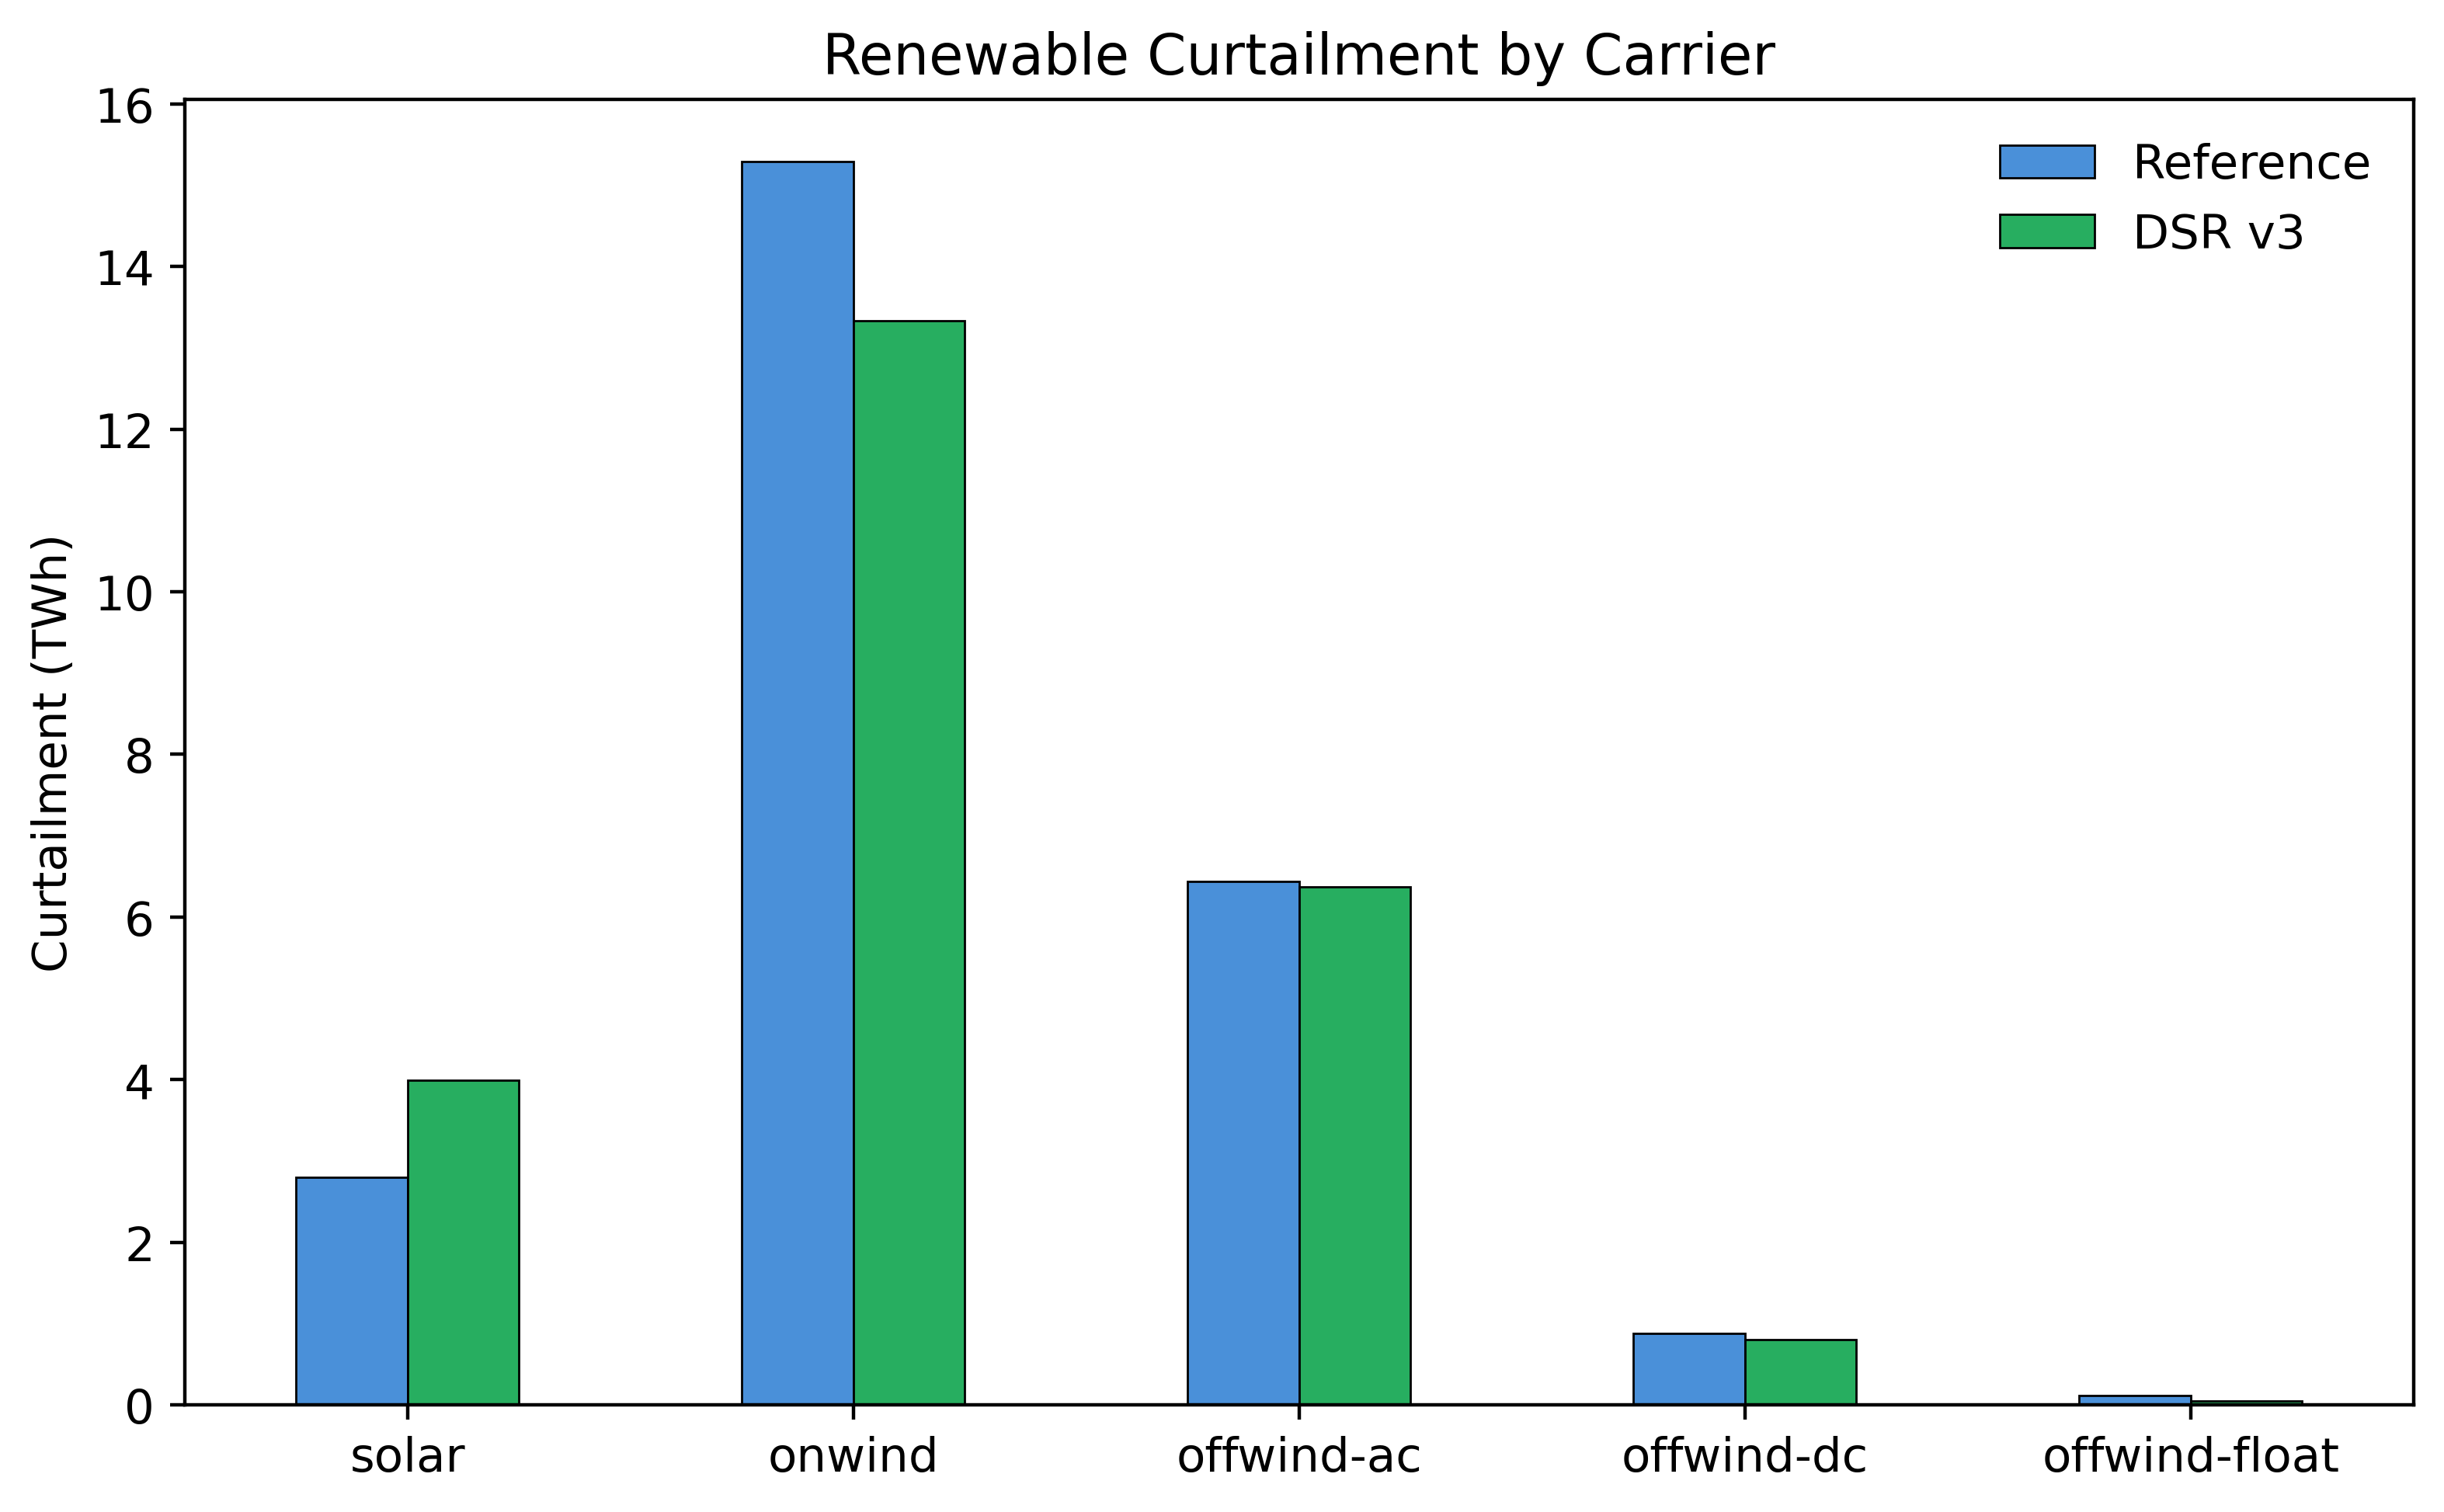

In [6]:
re_carriers = ['solar', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']

results = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    potential = (n_.generators_t.p_max_pu[re.index] * re.p_nom_opt).sum().sum()
    actual = n_.generators_t.p[re.index].sum().sum()
    curtailed = potential - actual
    results[label] = {'potential': potential/1e6, 'actual': actual/1e6, 'curtailed': curtailed/1e6,
                      'pct': curtailed/potential*100}
    print(f'{label}: Curtailed {curtailed/1e6:.2f} TWh ({curtailed/potential*100:.2f}%)')

curt_reduction = (results['DSR v3']['curtailed'] - results['Reference']['curtailed']) / results['Reference']['curtailed'] * 100
print(f'\nDSR reduces curtailment by {-curt_reduction:.0f}%')

# Curtailment by carrier
fig, ax = plt.subplots(figsize=(8, 5))
carrier_curt = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    for c in re_carriers:
        gens_c = re[re.carrier == c]
        if gens_c.empty:
            continue
        pot = (n_.generators_t.p_max_pu[gens_c.index] * gens_c.p_nom_opt).sum().sum()
        act = n_.generators_t.p[gens_c.index].sum().sum()
        carrier_curt.setdefault(c, {})[label] = (pot - act) / 1e6

df_curt = pd.DataFrame(carrier_curt).T
df_curt.plot(kind='bar', ax=ax, color=['#4a90d9', '#27ae60'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Curtailment (TWh)')
ax.set_title('Renewable Curtailment by Carrier')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. DSR Store Utilization

Total DSR stores: 367
Stores with capacity built: 330
Total capacity available: 305626 MWh
Total capacity built: 296393 MWh (97.0%)
Capital cost: 3.0 EUR/MWh/year
Total DSR investment: 0.89 M EUR/year


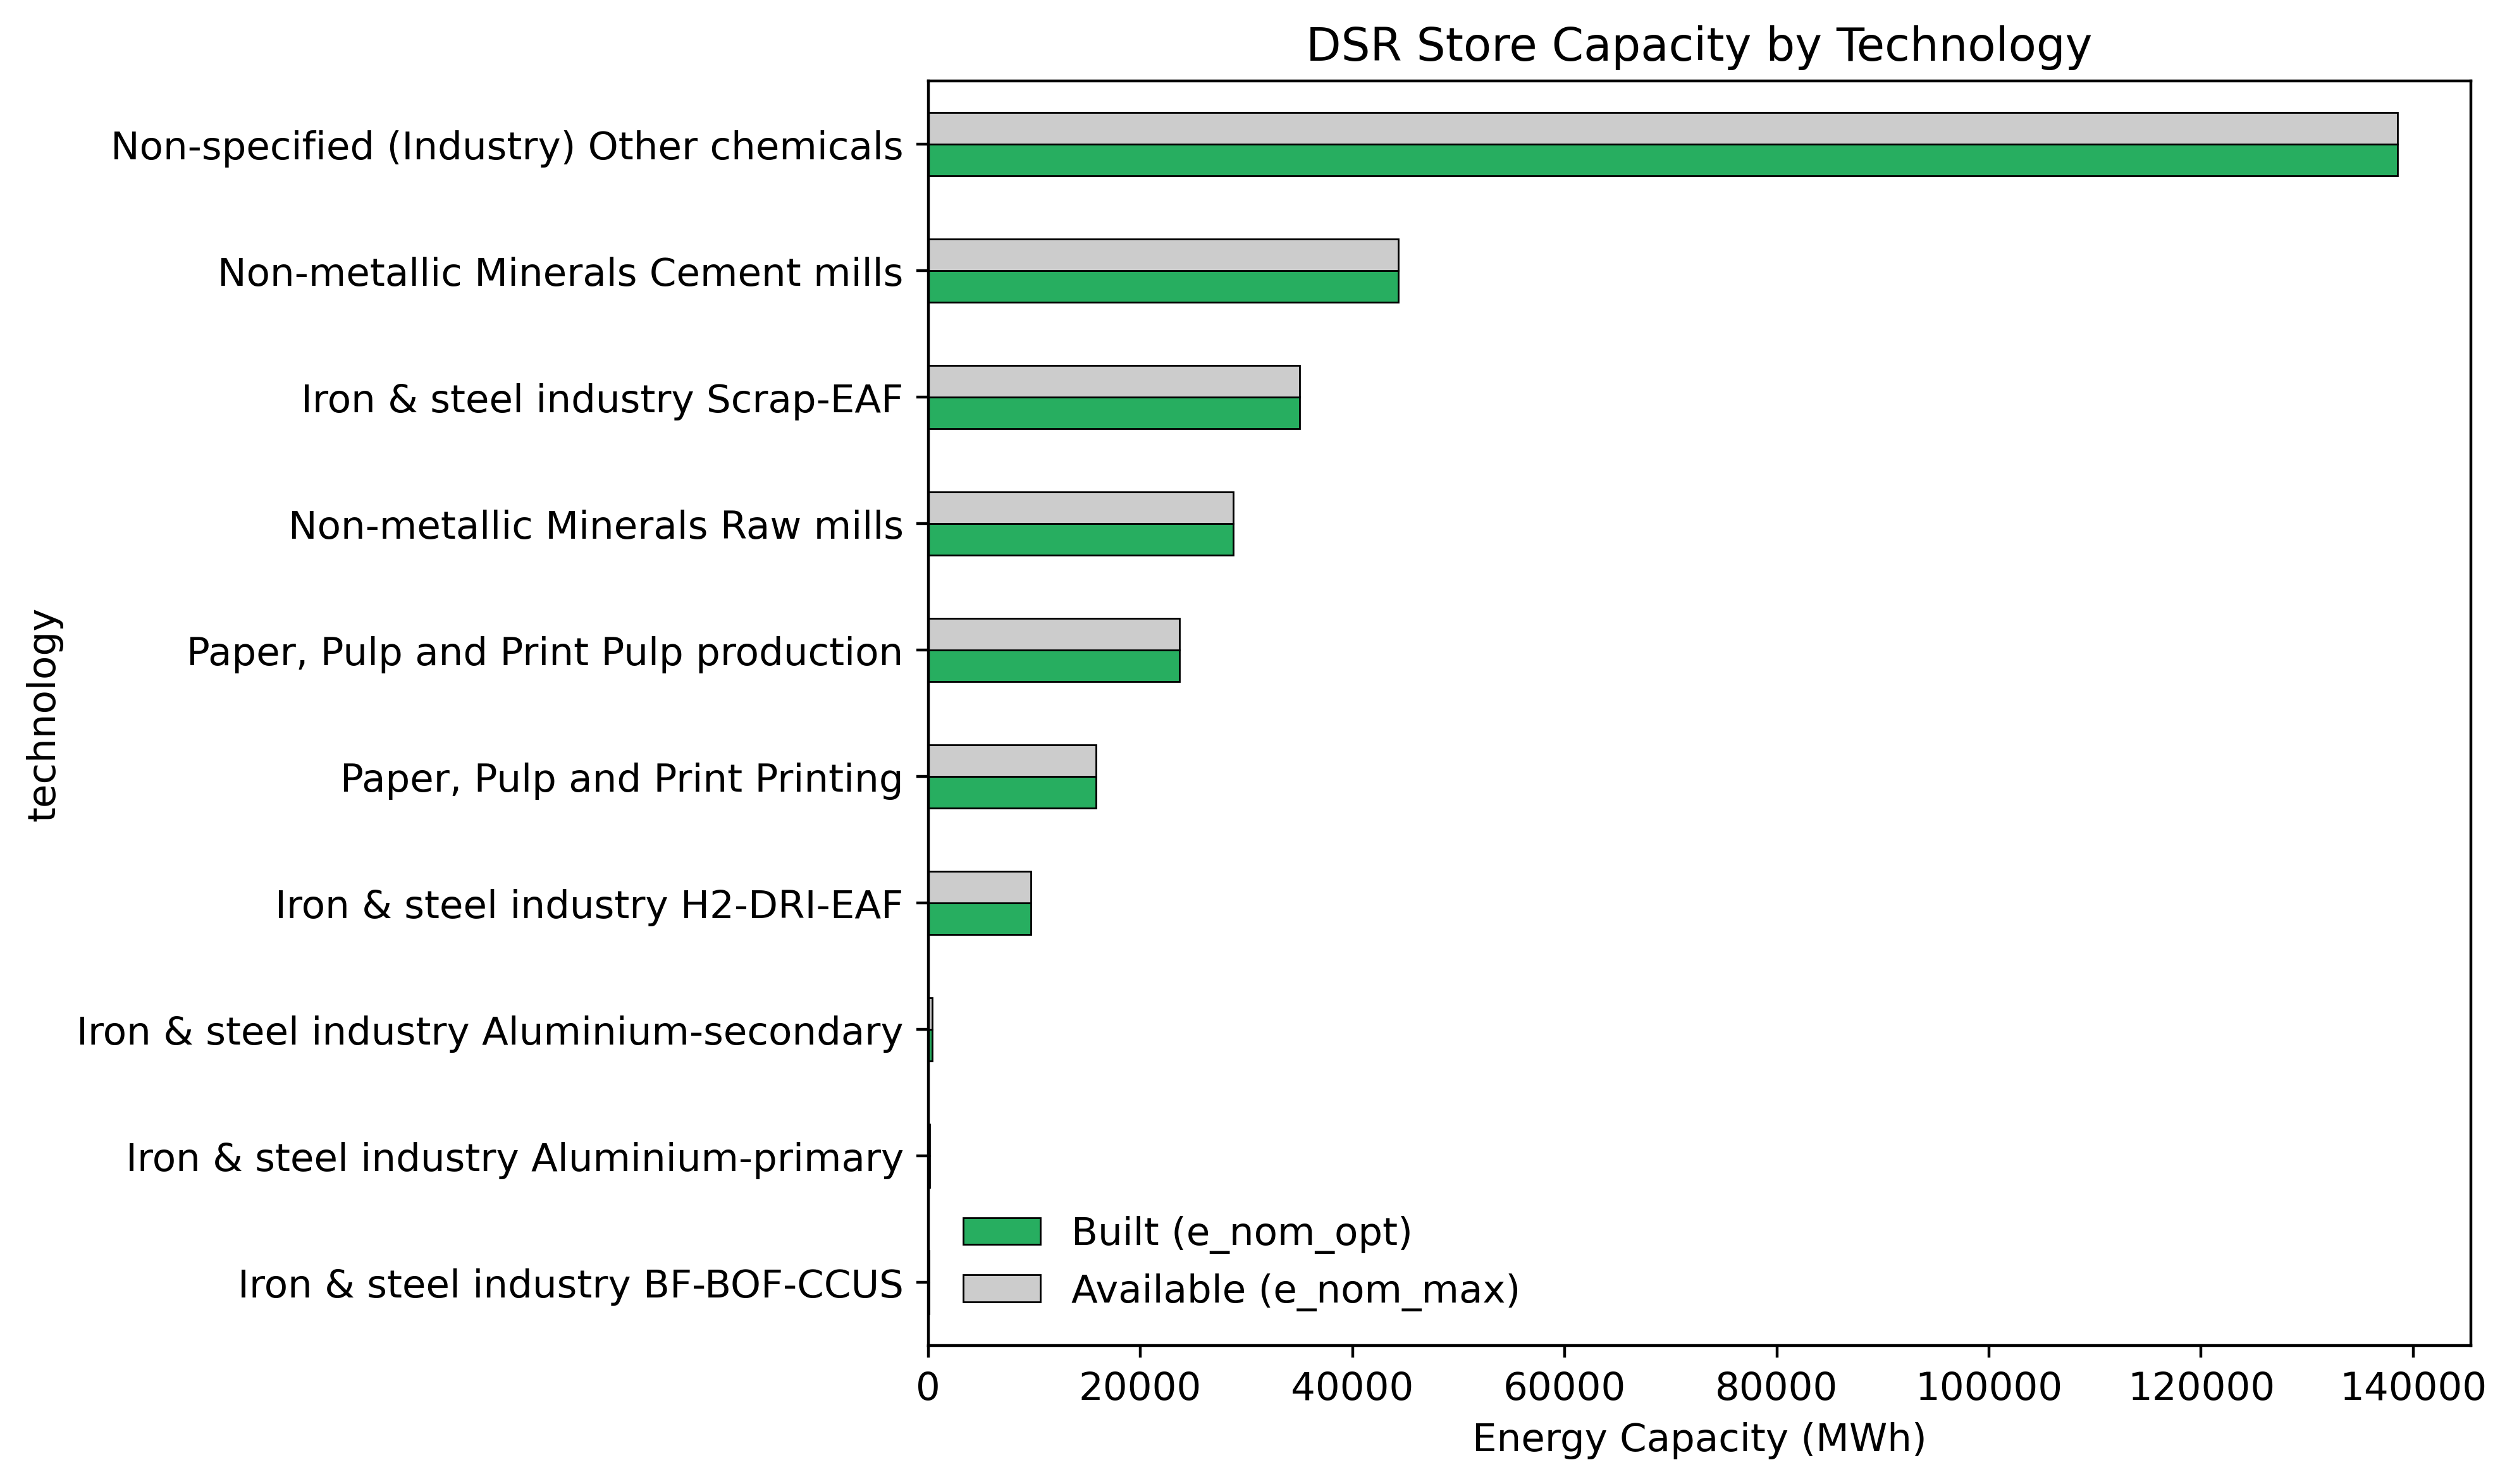

In [7]:
dsr_stores = n_dsr.stores[n_dsr.stores.carrier == 'industry dsr']

print(f'Total DSR stores: {len(dsr_stores)}')
print(f'Stores with capacity built: {(dsr_stores.e_nom_opt > 0).sum()}')
print(f'Total capacity available: {dsr_stores.e_nom_max.sum():.0f} MWh')
print(f'Total capacity built: {dsr_stores.e_nom_opt.sum():.0f} MWh ({dsr_stores.e_nom_opt.sum()/dsr_stores.e_nom_max.sum()*100:.1f}%)')
print(f'Capital cost: {dsr_stores.capital_cost.iloc[0]:.1f} EUR/MWh/year')
print(f'Total DSR investment: {(dsr_stores.e_nom_opt * dsr_stores.capital_cost).sum()/1e6:.2f} M EUR/year')

# Store capacity by technology
dsr_stores_built = dsr_stores[dsr_stores.e_nom_opt > 0].copy()
dsr_stores_built['technology'] = dsr_stores_built.index.map(
    lambda x: x.split(' industry dsr ')[-1] if ' industry dsr ' in x else 'unknown'
)

tech_cap = dsr_stores_built.groupby('technology')[['e_nom_opt', 'e_nom_max']].sum()
tech_cap = tech_cap.sort_values('e_nom_opt', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
tech_cap.plot(kind='barh', ax=ax, color=['#27ae60', '#cccccc'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Energy Capacity (MWh)')
ax.set_title('DSR Store Capacity by Technology')
ax.legend(['Built (e_nom_opt)', 'Available (e_nom_max)'])
plt.tight_layout()
plt.show()

## 5. DSR Dispatch Profile

Total energy charged (increased demand): 26.21 TWh
Total energy discharged (reduced demand): 25.68 TWh
Efficiency loss: 0.52 TWh
Peak charge power: 41.6 GW
Peak discharge power: 43.3 GW


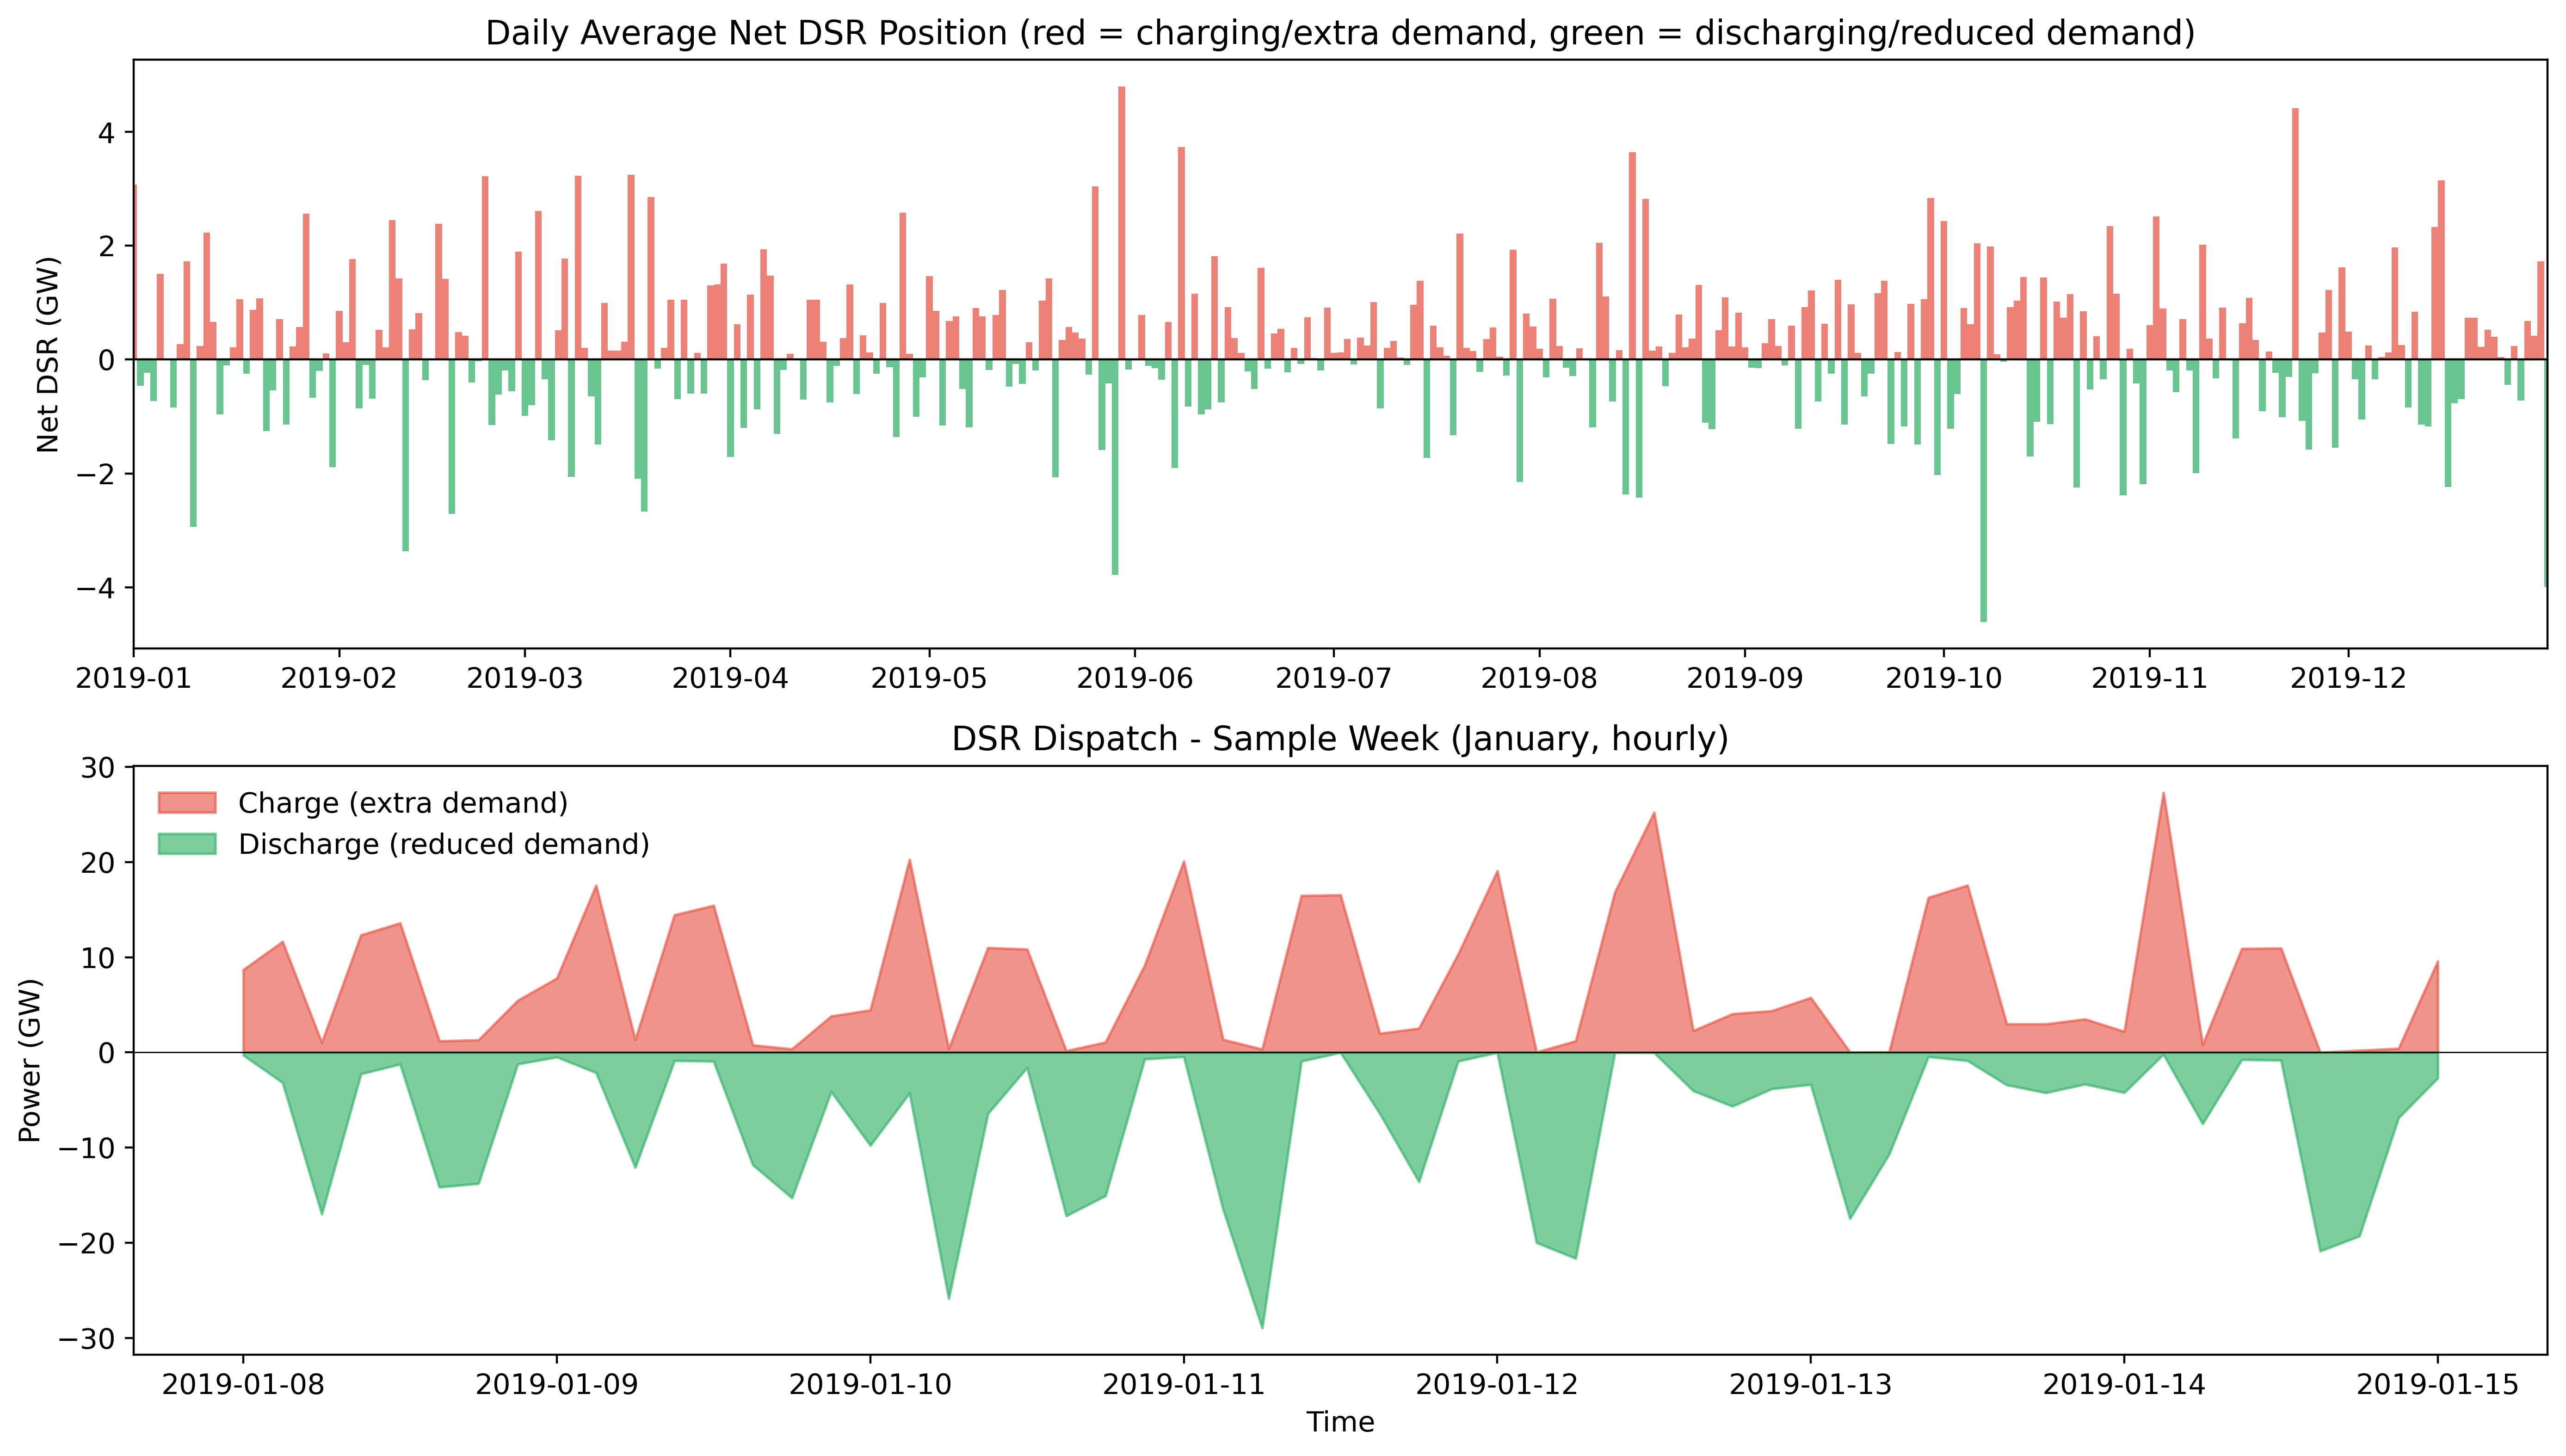

In [8]:
# Charge and discharge link flows
ch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr charge']
dch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr discharge']

charge_total = n_dsr.links_t.p0[ch_links.index].sum(axis=1)
discharge_total = n_dsr.links_t.p0[dch_links.index].sum(axis=1)
net_dsr = charge_total - discharge_total  # positive = extra demand, negative = reduced demand

print(f'Total energy charged (increased demand): {charge_total.sum()/1e6:.2f} TWh')
print(f'Total energy discharged (reduced demand): {discharge_total.sum()/1e6:.2f} TWh')
print(f'Efficiency loss: {(charge_total.sum()-discharge_total.sum())/1e6:.2f} TWh')
print(f'Peak charge power: {charge_total.max()/1e3:.1f} GW')
print(f'Peak discharge power: {discharge_total.max()/1e3:.1f} GW')

# --- PLOT 1: Net DSR position over the year (daily average) ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

ax = axes[0]
daily_net = net_dsr.resample('D').mean() / 1e3  # GW
colors_net = ['#e74c3c' if v > 0 else '#27ae60' for v in daily_net.values]
ax.bar(daily_net.index, daily_net.values, color=colors_net, alpha=0.7, width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Net DSR (GW)')
ax.set_title('Daily Average Net DSR Position (red = charging/extra demand, green = discharging/reduced demand)')
ax.set_xlim(daily_net.index[0], daily_net.index[-1])

# --- PLOT 2: Sample week with hourly dispatch ---
ax = axes[1]
jan_start = charge_total.index[0] + pd.Timedelta(days=7)
jan_end = jan_start + pd.Timedelta(days=7)
ch_week = charge_total[jan_start:jan_end]
dch_week = discharge_total[jan_start:jan_end]
ax.fill_between(ch_week.index, 0, ch_week.values/1e3, alpha=0.6, color='#e74c3c', label='Charge (extra demand)')
ax.fill_between(dch_week.index, 0, -dch_week.values/1e3, alpha=0.6, color='#27ae60', label='Discharge (reduced demand)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Power (GW)')
ax.set_xlabel('Time')
ax.set_title('DSR Dispatch - Sample Week (January, hourly)')
ax.legend()

plt.tight_layout()
plt.show()

### 5b. DSR Response to Price Signals

The core rationale of DSR: **charge (increase demand) when electricity is cheap, discharge (reduce demand) when expensive**. The plots below show this behavior on representative days.

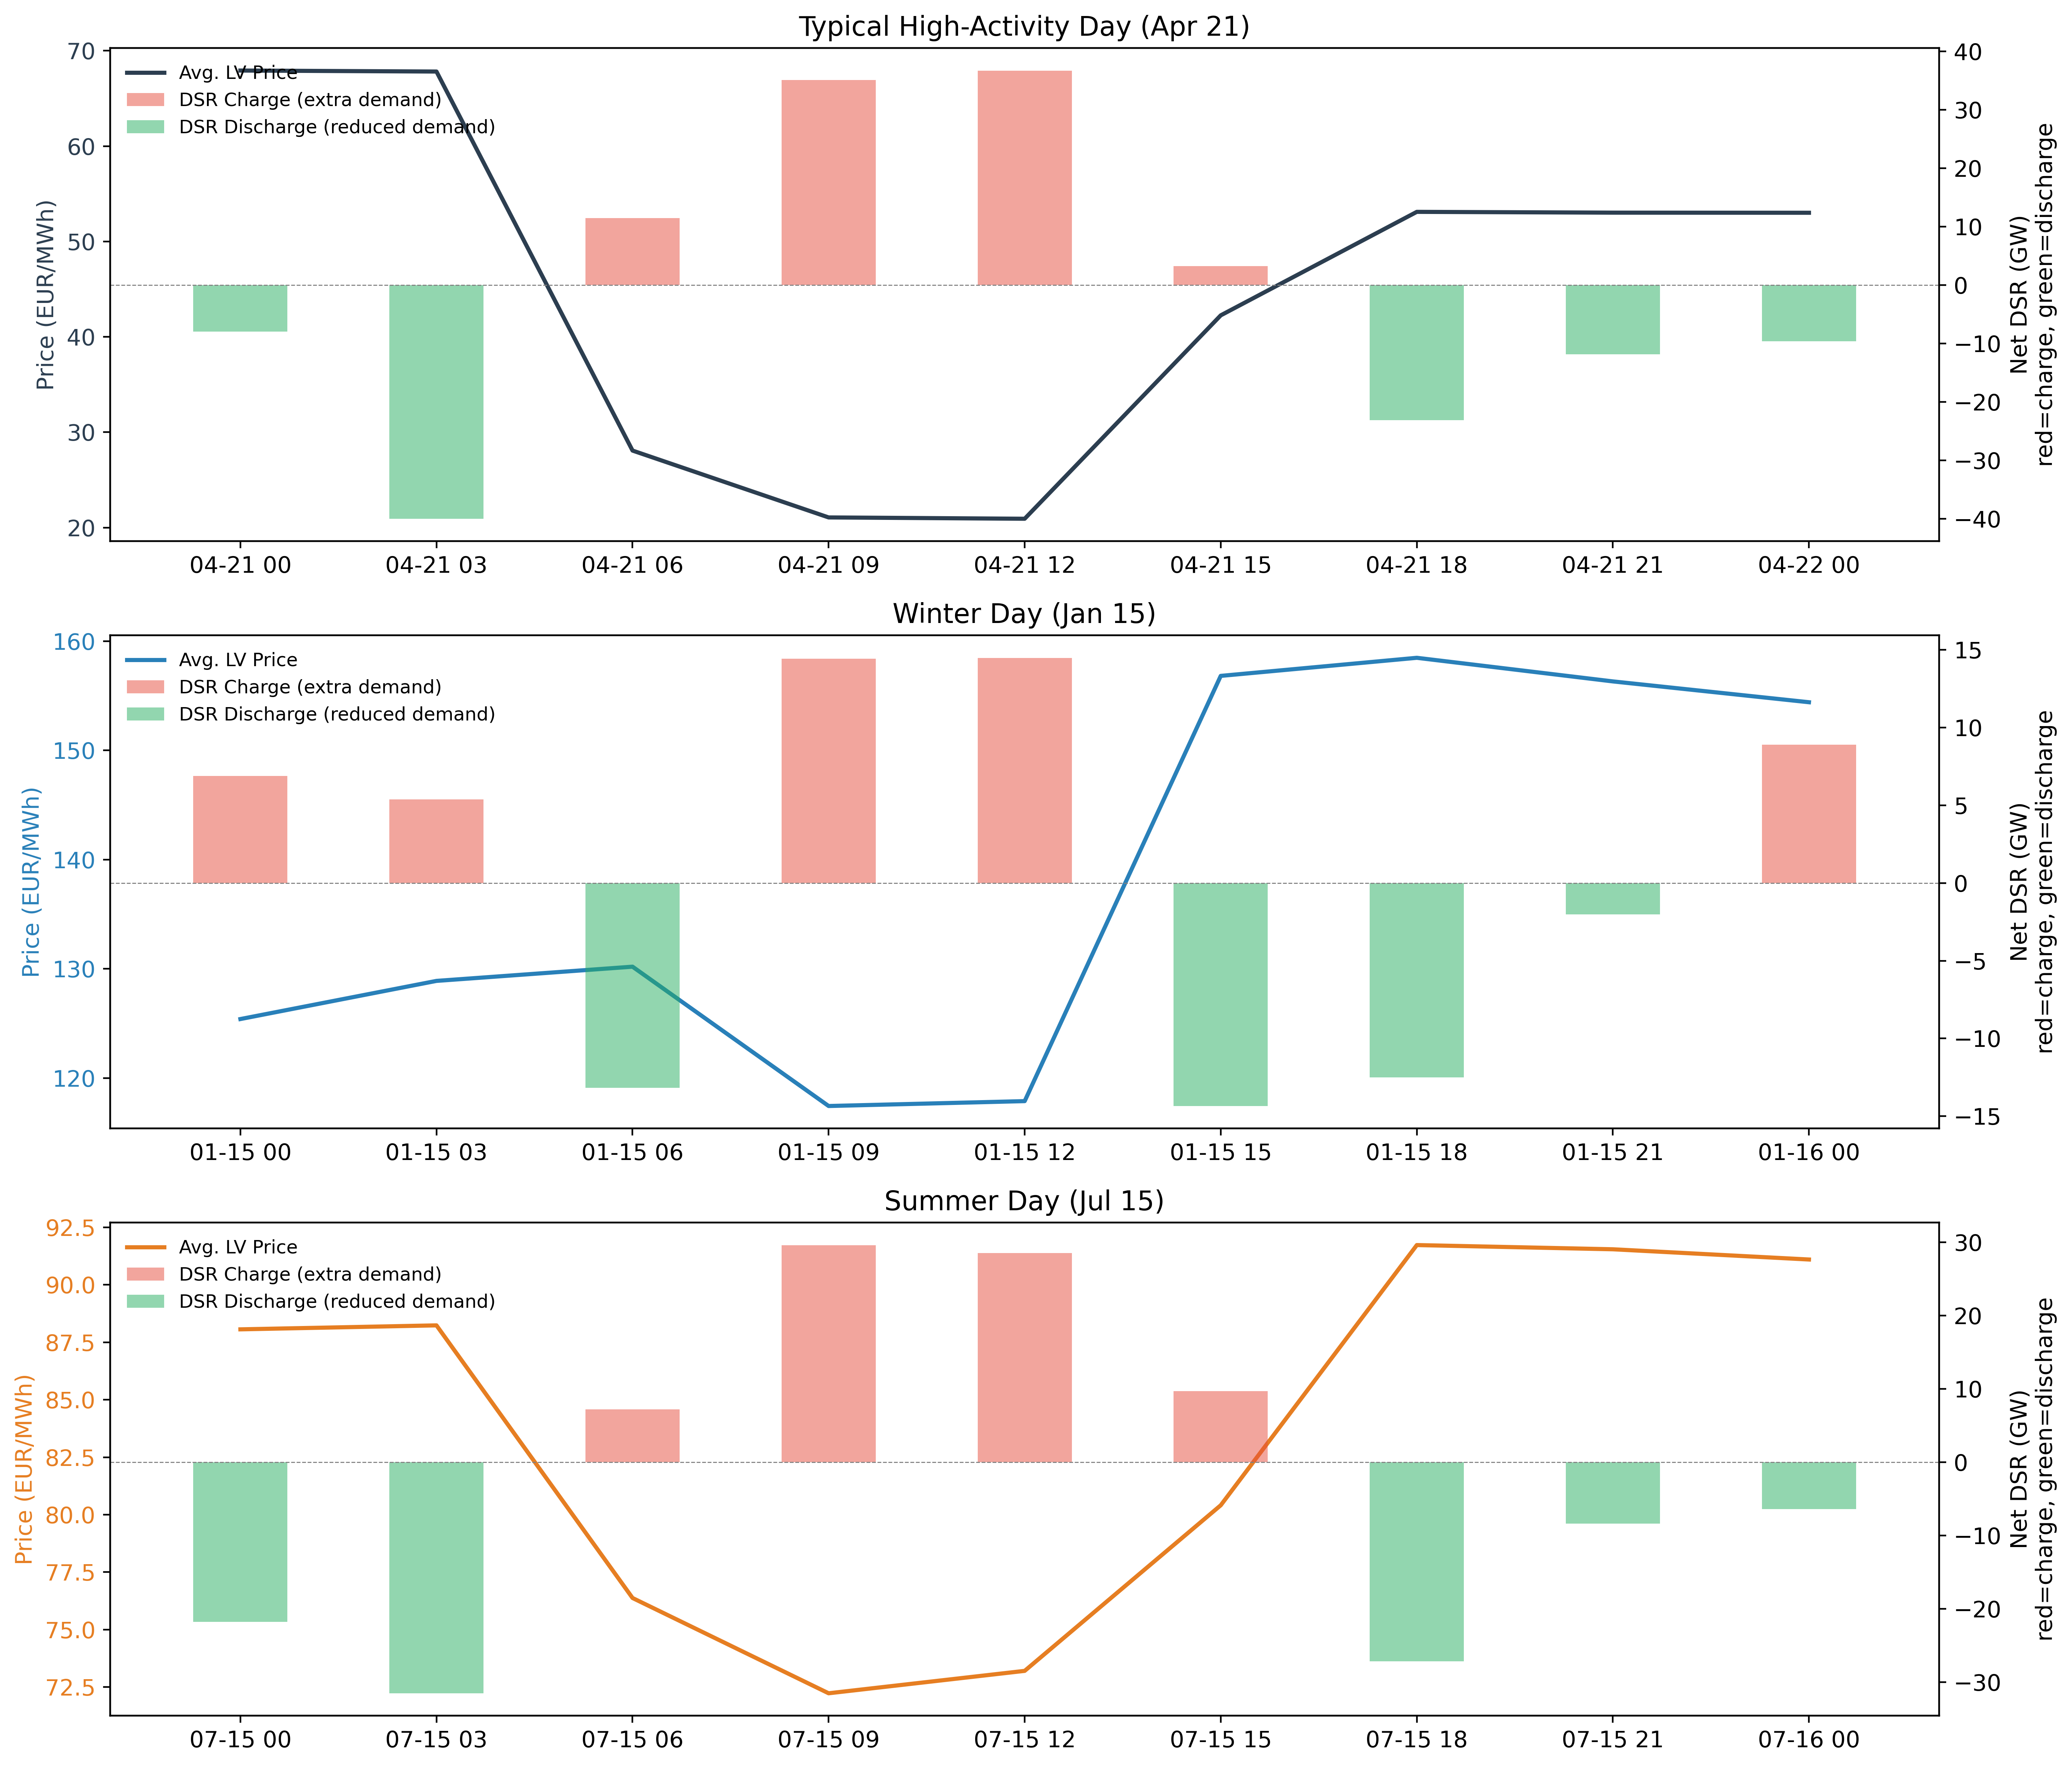


Expected behavior: DSR charges (red bars) during LOW price hours
and discharges (green bars) during HIGH price hours.


In [9]:
# Get system-wide average AC grid price from the DSR run
ac_buses_dsr = [b for b in n_dsr.buses.index if n_dsr.buses.loc[b, 'carrier'] == 'AC']
price_hourly = n_dsr.buses_t.marginal_price[ac_buses_dsr].mean(axis=1)

# Find a typical high-activity day (90th percentile swing, avoids extreme outliers)
daily_swing = net_dsr.groupby(net_dsr.index.date).apply(lambda x: x.max() - x.min())
p90_threshold = daily_swing.quantile(0.90)
# Pick the day closest to the 90th percentile
typical_active_day = pd.Timestamp((daily_swing - p90_threshold).abs().idxmin())

# Also pick a typical winter day and a summer day for comparison
winter_day = pd.Timestamp('2019-01-15')
summer_day = pd.Timestamp('2019-07-15')

days_to_plot = [
    (typical_active_day, f'Typical High-Activity Day ({typical_active_day.strftime("%b %d")})', '#2c3e50'),
    (winter_day, 'Winter Day (Jan 15)', '#2980b9'),
    (summer_day, 'Summer Day (Jul 15)', '#e67e22'),
]

fig, axes = plt.subplots(len(days_to_plot), 1, figsize=(14, 4 * len(days_to_plot)))

for idx, (day, title, color) in enumerate(days_to_plot):
    ax1 = axes[idx]
    day_end = day + pd.Timedelta(days=1)
    
    # Price on left axis
    price_day = price_hourly[day:day_end]
    ax1.plot(price_day.index, price_day.values, color=color, linewidth=2, label='Avg. Grid Price')
    ax1.set_ylabel('Price (EUR/MWh)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Net DSR on right axis
    ax2 = ax1.twinx()
    net_day = net_dsr[day:day_end]
    net_colors = ['#e74c3c' if v > 0 else '#27ae60' for v in net_day.values]
    ax2.bar(net_day.index, net_day.values / 1e3, color=net_colors, alpha=0.5, width=0.06, label='Net DSR')
    ax2.set_ylabel('Net DSR (GW)\nred=charge, green=discharge')
    ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    
    ax1.set_title(title)
    
    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    from matplotlib.patches import Patch
    charge_patch = Patch(facecolor='#e74c3c', alpha=0.5, label='DSR Charge (extra demand)')
    discharge_patch = Patch(facecolor='#27ae60', alpha=0.5, label='DSR Discharge (reduced demand)')
    ax1.legend(handles=lines1 + [charge_patch, discharge_patch], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('\nExpected behavior: DSR charges (red bars) during LOW price hours')
print('and discharges (green bars) during HIGH price hours.')

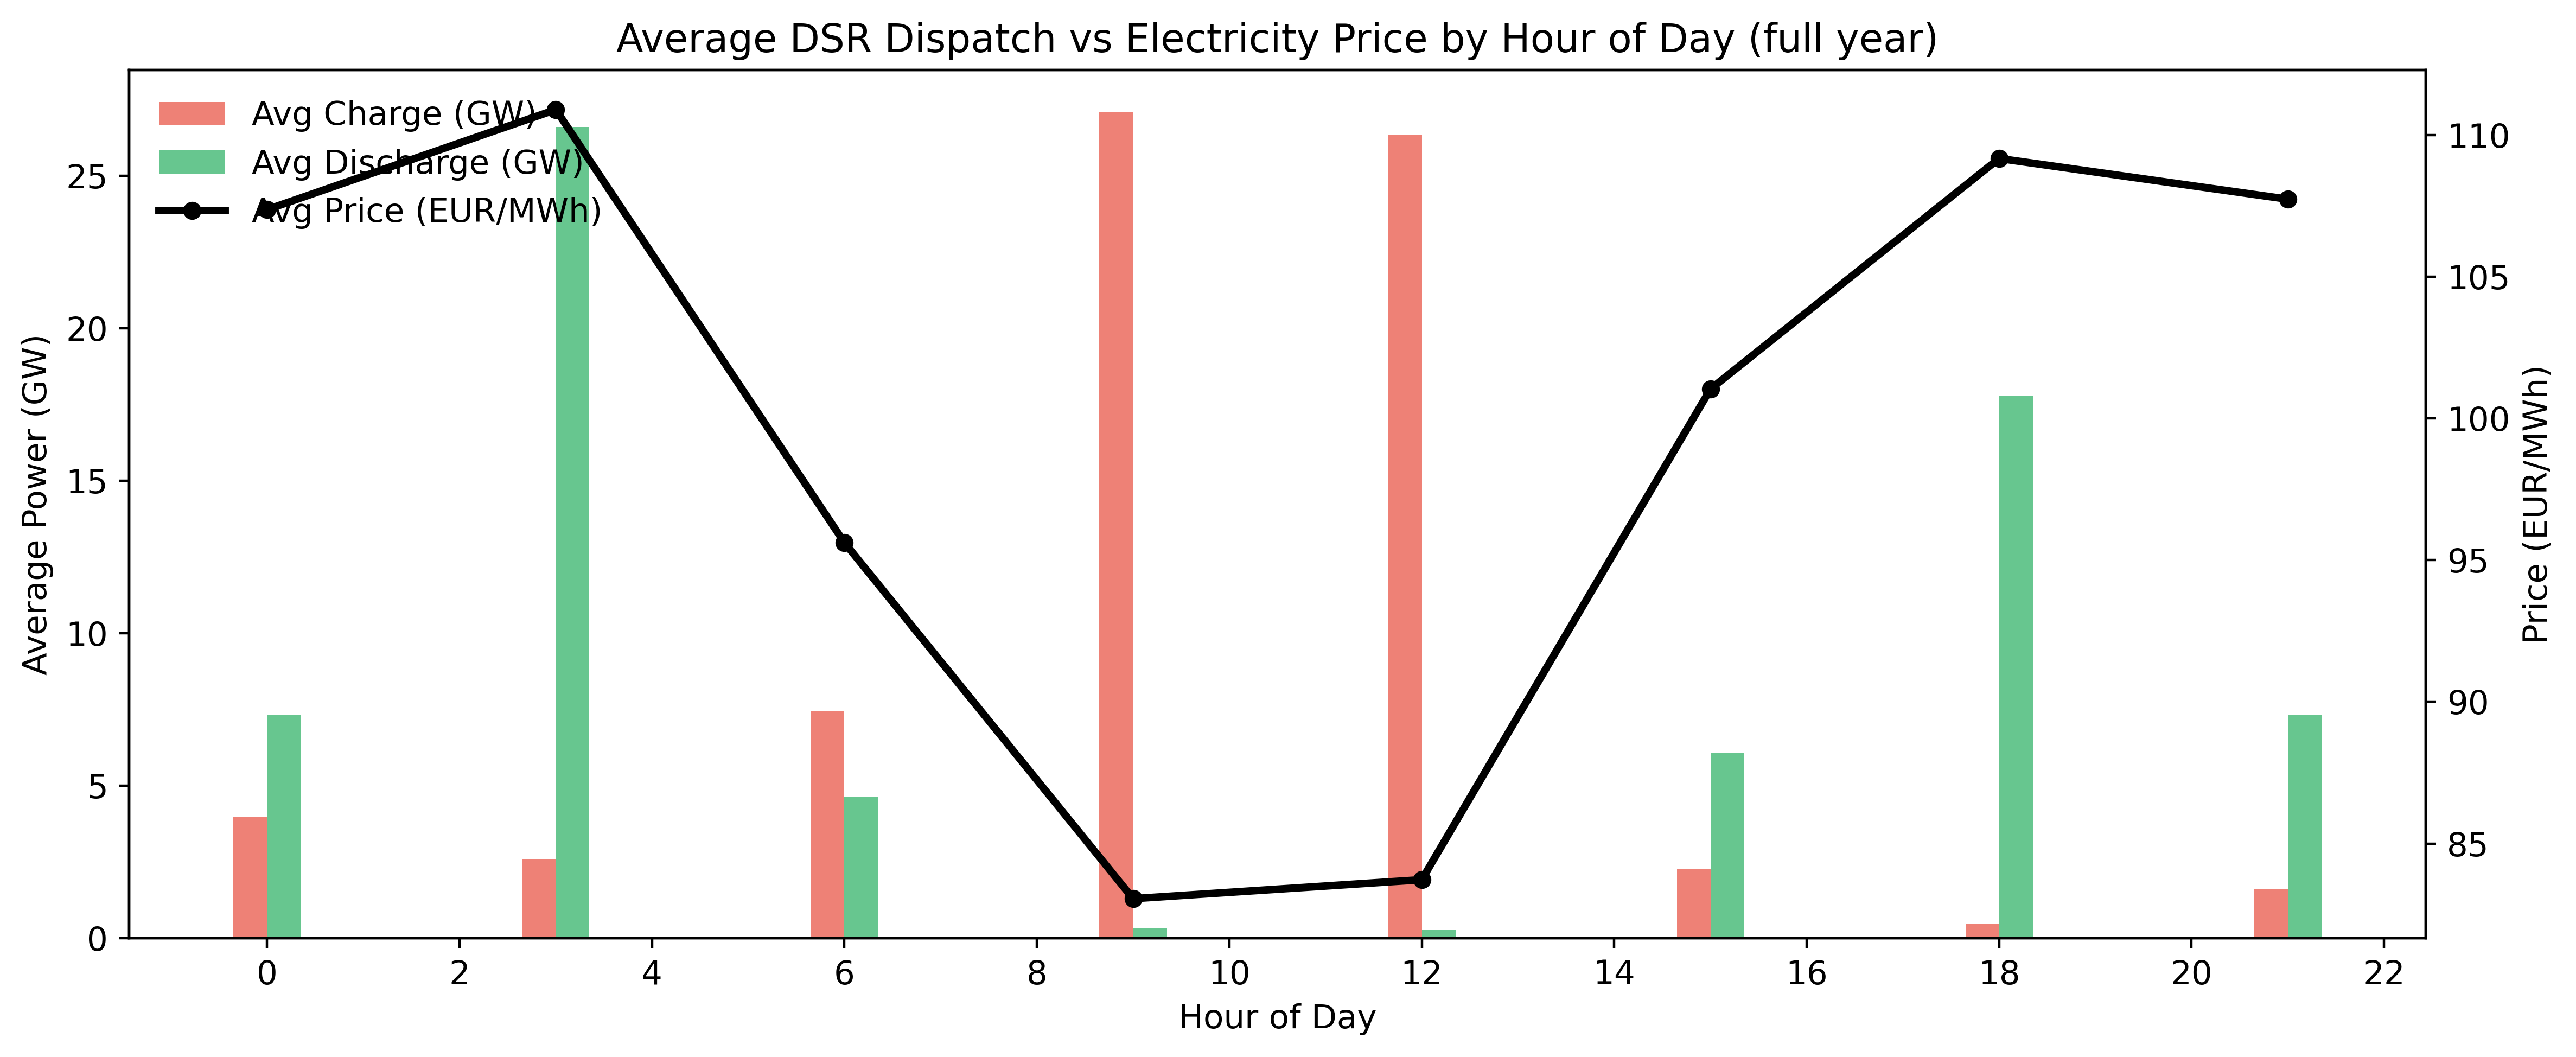

If DSR is rational: charge should be higher during low-price hours,
discharge should be higher during high-price hours.


In [10]:
# Average DSR behavior by hour of day (across entire year) vs average price
avg_charge_by_hour = charge_total.groupby(charge_total.index.hour).mean() / 1e3
avg_discharge_by_hour = discharge_total.groupby(discharge_total.index.hour).mean() / 1e3
avg_price_by_hour = price_hourly.groupby(price_hourly.index.hour).mean()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Stacked bars for charge/discharge
hours = avg_charge_by_hour.index
width = 0.35
ax1.bar(hours - width/2, avg_charge_by_hour.values, width, color='#e74c3c', alpha=0.7, label='Avg Charge (GW)')
ax1.bar(hours + width/2, avg_discharge_by_hour.values, width, color='#27ae60', alpha=0.7, label='Avg Discharge (GW)')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Power (GW)')
ax1.set_xticks(range(0, 24, 2))

# Price overlay on right axis
ax2 = ax1.twinx()
ax2.plot(hours, avg_price_by_hour.values, 'ko-', linewidth=2.5, markersize=5, label='Avg Price (EUR/MWh)')
ax2.set_ylabel('Price (EUR/MWh)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('Average DSR Dispatch vs Electricity Price by Hour of Day (full year)')
plt.tight_layout()
plt.show()

print('If DSR is rational: charge should be higher during low-price hours,')
print('discharge should be higher during high-price hours.')

## 6. Price Impact of DSR by Hour of Day

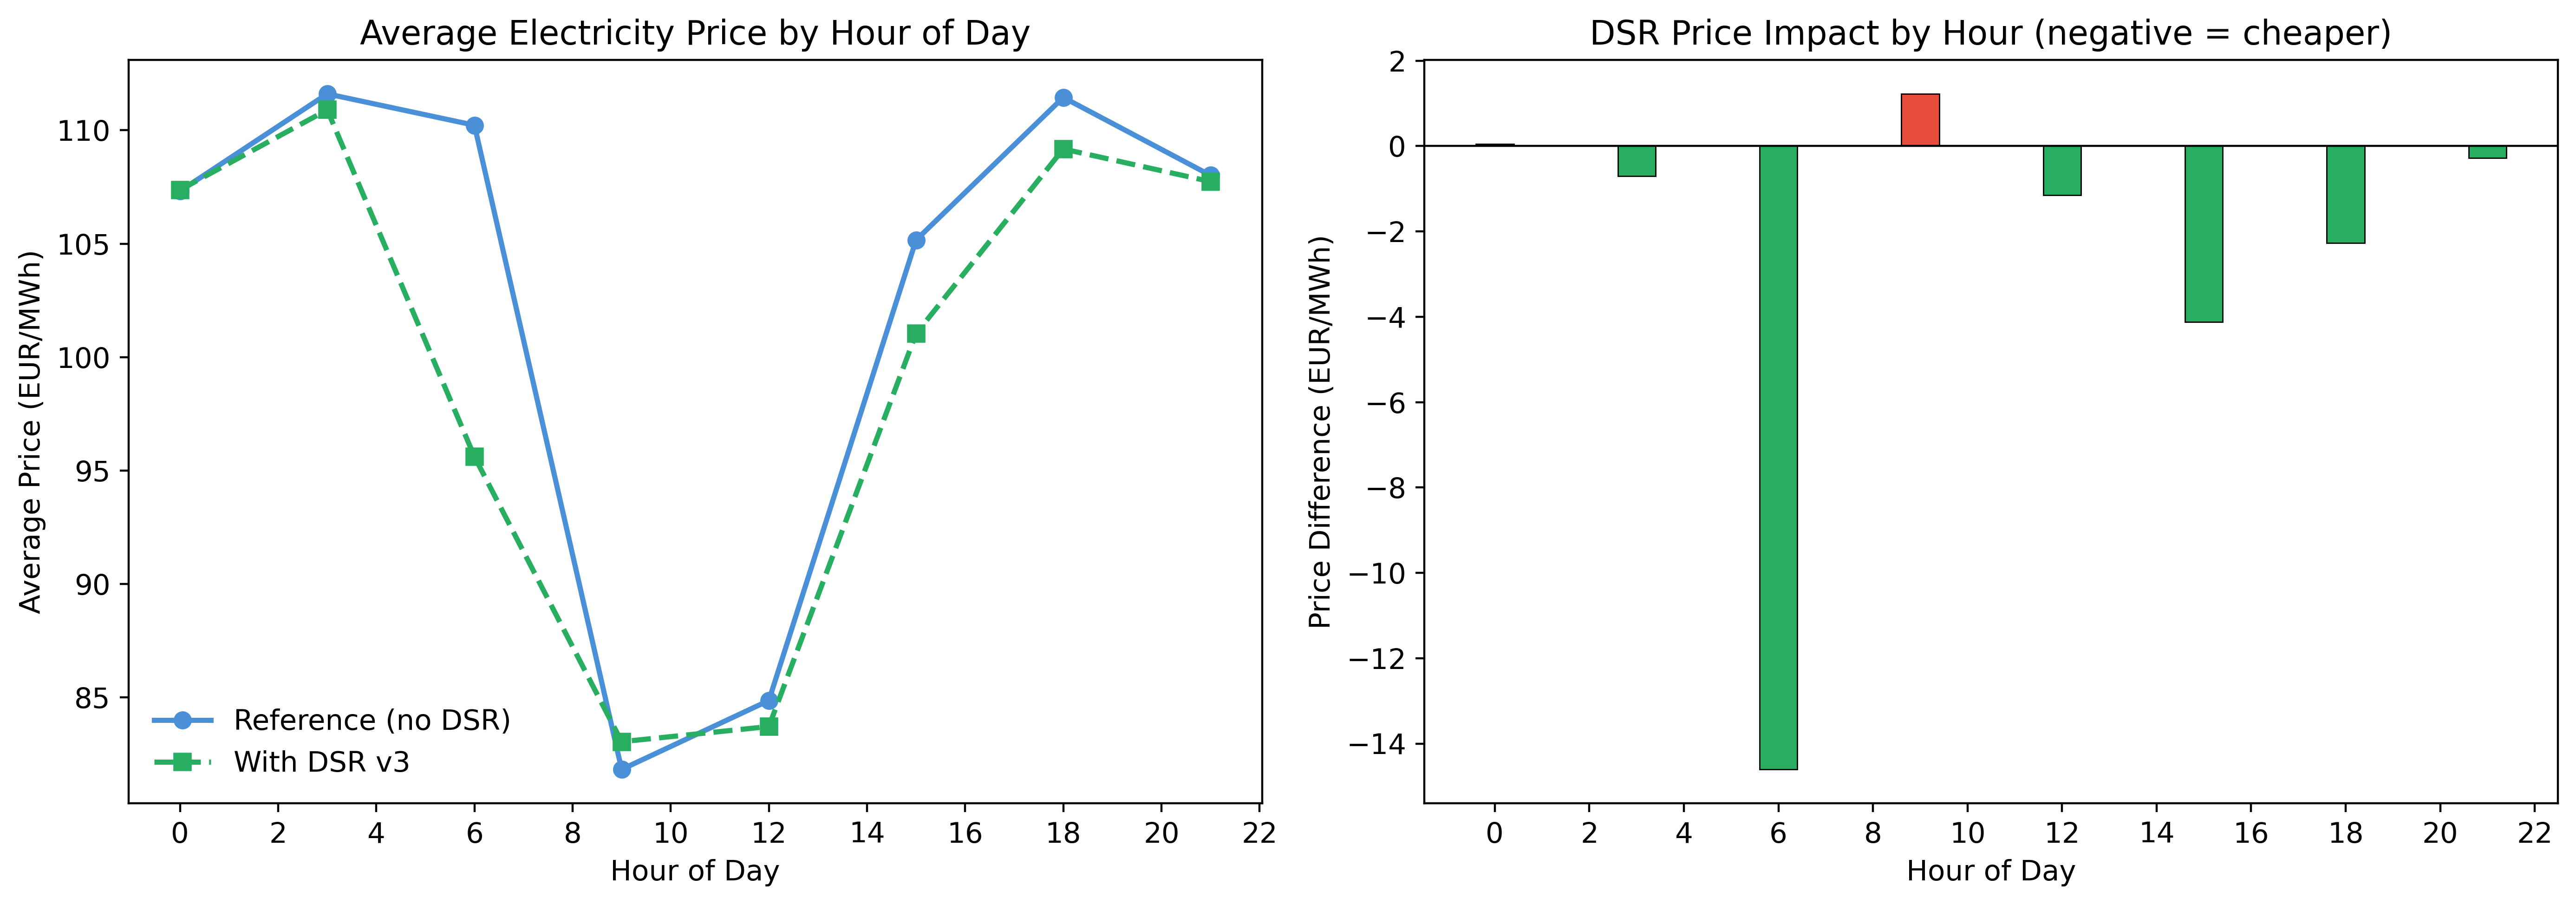

In [11]:
# Average price by hour of day
hourly_ref = prices_ref.mean(axis=1)
hourly_dsr_price = prices_dsr.mean(axis=1)

by_hour_ref = hourly_ref.groupby(hourly_ref.index.hour).mean()
by_hour_dsr = hourly_dsr_price.groupby(hourly_dsr_price.index.hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(by_hour_ref.index, by_hour_ref.values, 'o-', label='Reference (no DSR)', color='#4a90d9', linewidth=2)
ax.plot(by_hour_dsr.index, by_hour_dsr.values, 's--', label='With DSR v3', color='#27ae60', linewidth=2)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Price (EUR/MWh)')
ax.set_title('Average Electricity Price by Hour of Day')
ax.legend()
ax.set_xticks(range(0, 24, 2))

# Price difference by hour
ax = axes[1]
price_diff_hour = by_hour_dsr - by_hour_ref
colors = ['#27ae60' if v < 0 else '#e74c3c' for v in price_diff_hour.values]
ax.bar(price_diff_hour.index, price_diff_hour.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Price Difference (EUR/MWh)')
ax.set_title('DSR Price Impact by Hour (negative = cheaper)')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 7. Generation Mix Comparison

Generation by carrier (TWh):
               Reference  DSR v3  Difference
carrier                                     
oil primary        747.4   729.0       -18.4
onwind             471.5   465.7        -5.8
solar rooftop      359.1   360.5         1.4
solid biomass      345.0   345.0         0.0
gas                266.4   290.4        24.0
offwind-ac         233.0   231.5        -1.5
solar-hsat         228.6   202.7       -25.9
nuclear            185.0   186.7         1.7
solar               74.5    73.3        -1.2
ror                 49.1    49.1         0.0
coal                34.7    34.7         0.0
import H2           33.3    66.7        33.3
offwind-dc          29.4    29.5         0.0
offwind-float        1.4     1.5         0.1
biogas               0.0     0.0        -0.0


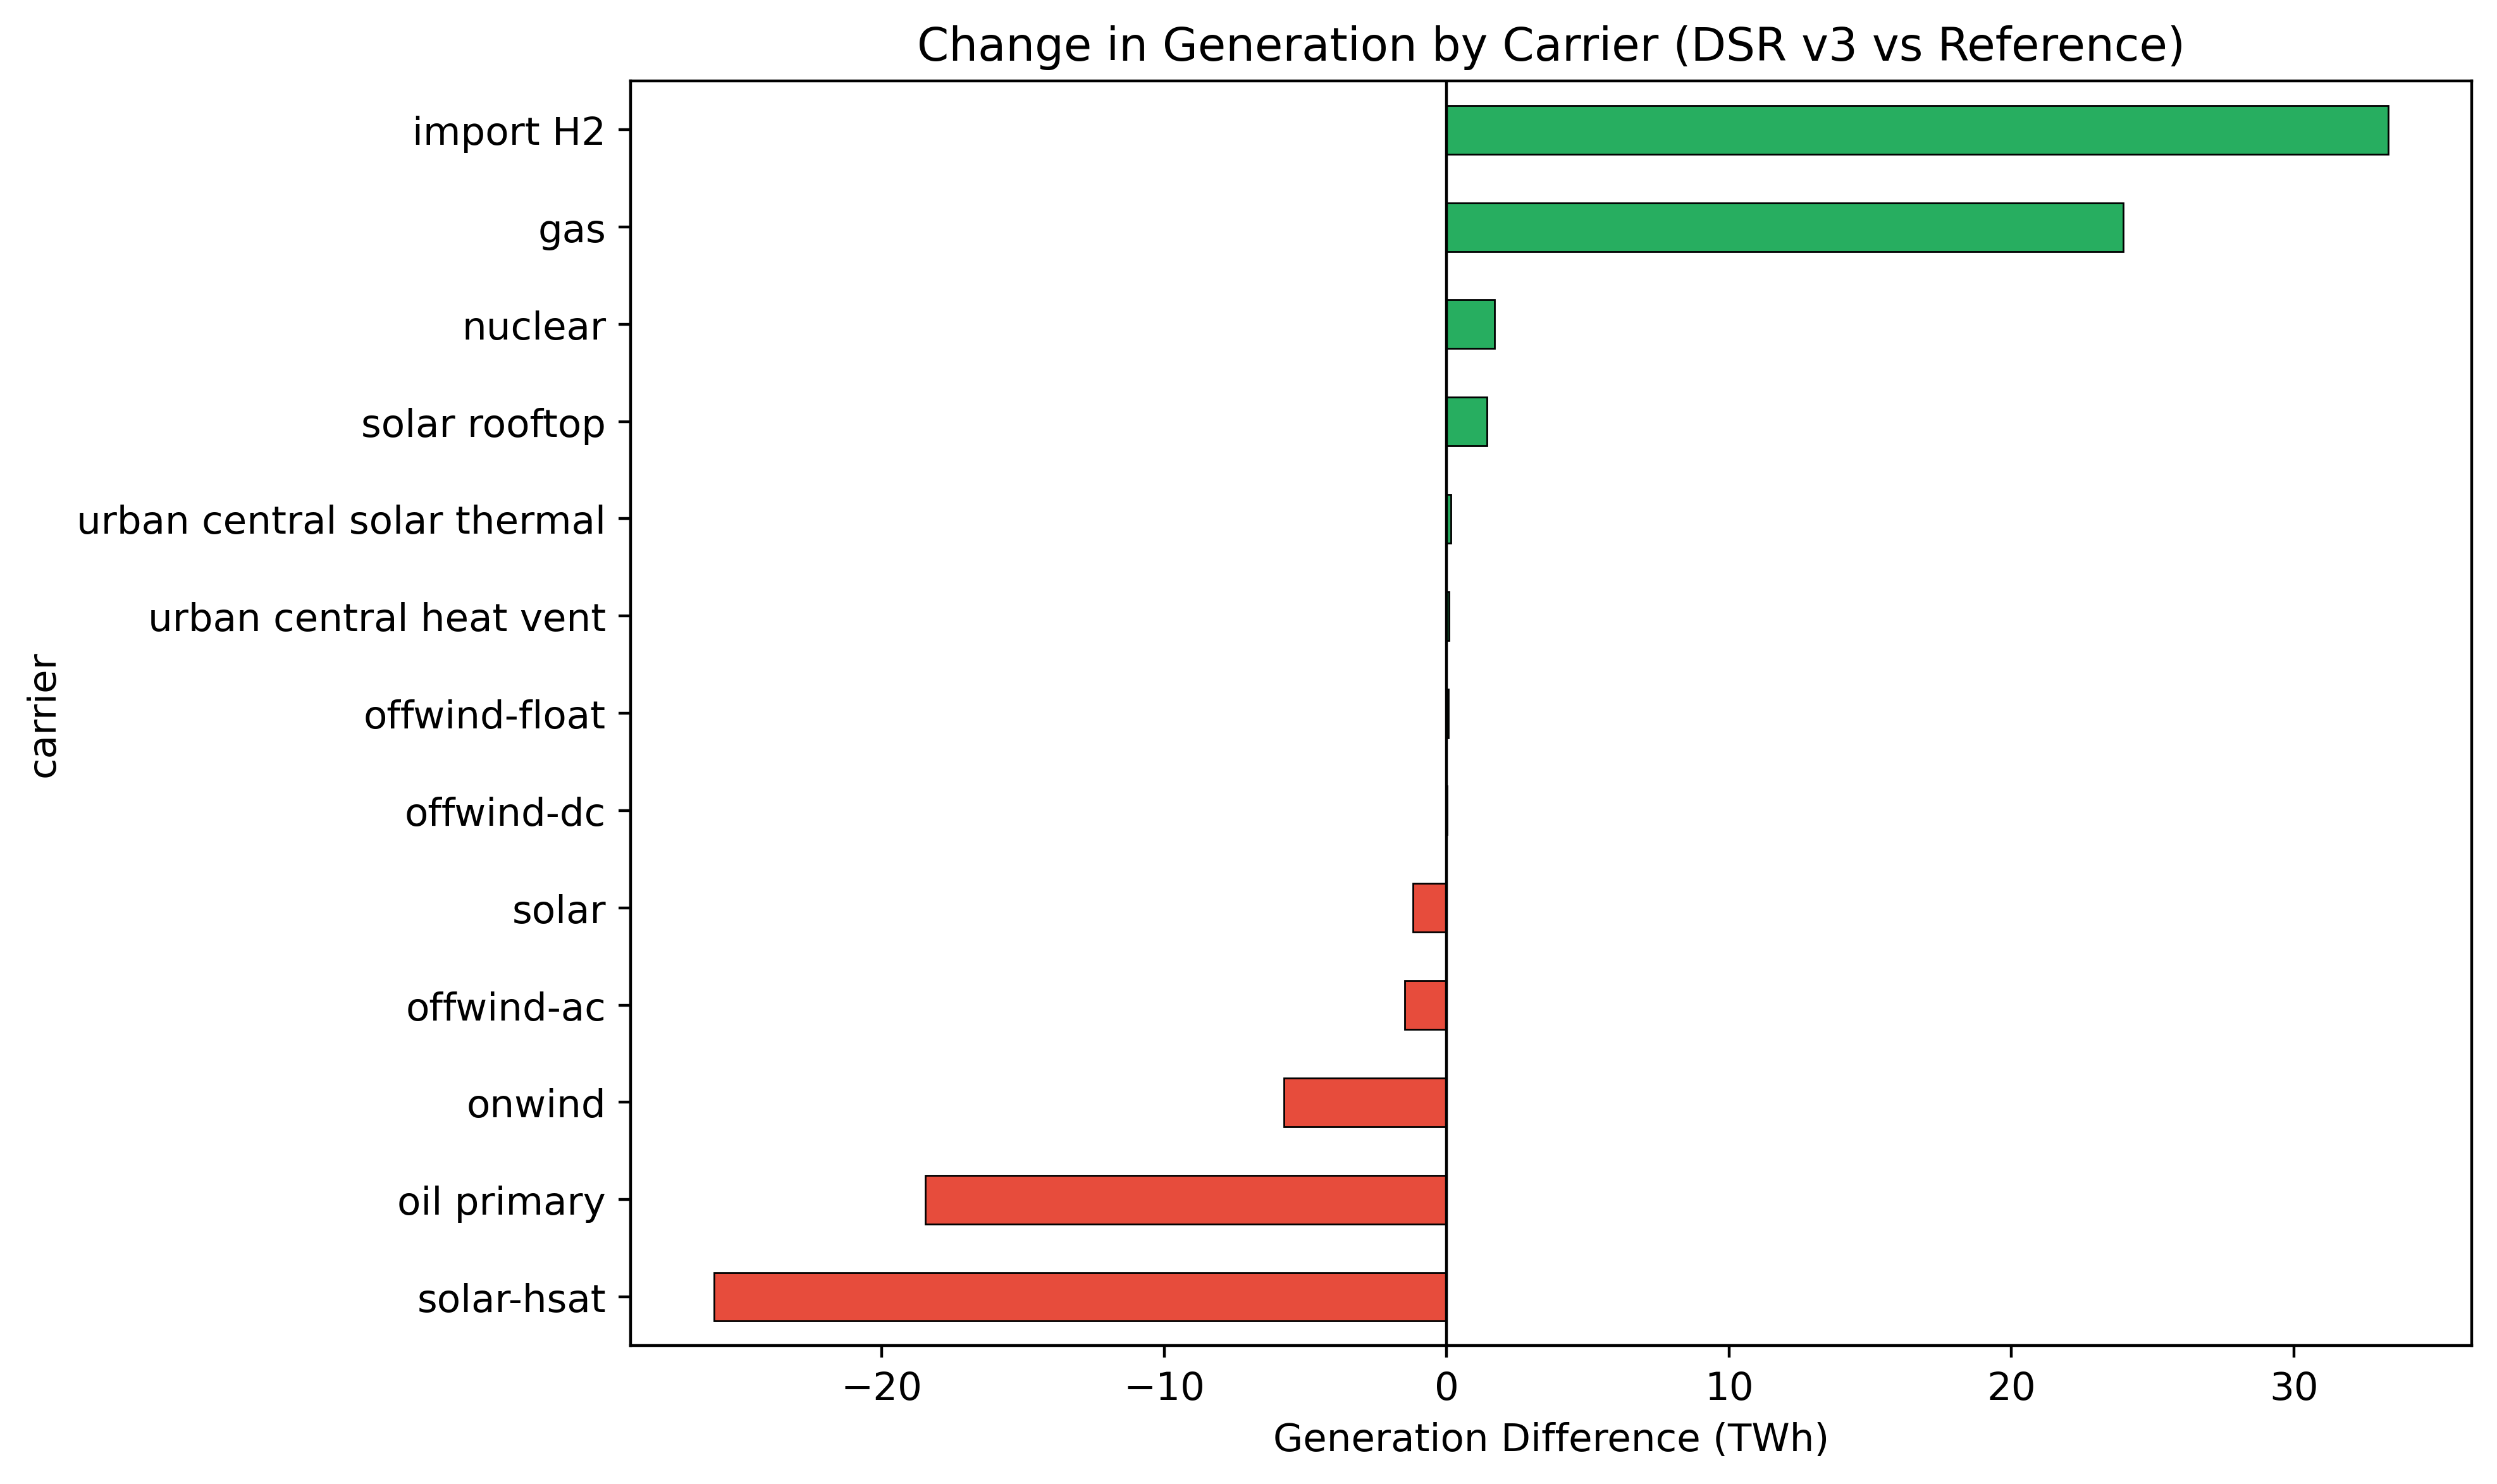

In [12]:
# Compare generation by carrier
gen_data = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    gen_by_carrier = n_.generators_t.p.sum().groupby(n_.generators.carrier).sum() / 1e6  # TWh
    gen_data[label] = gen_by_carrier

df_gen = pd.DataFrame(gen_data).fillna(0)
df_gen['Difference'] = df_gen['DSR v3'] - df_gen['Reference']
df_gen = df_gen.sort_values('Reference', ascending=False)

# Top carriers
top = df_gen.head(15)
print('Generation by carrier (TWh):')
print(top.to_string(float_format='{:.1f}'.format))

# Plot difference
diff_nonzero = df_gen[df_gen['Difference'].abs() > 0.01]['Difference'].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in diff_nonzero.values]
diff_nonzero.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Generation Difference (TWh)')
ax.set_title('Change in Generation by Carrier (DSR v3 vs Reference)')
plt.tight_layout()
plt.show()

## 8. Grid Deployment Comparison

Does DSR reduce the need for transmission grid reinforcement? Compare AC line and DC link expansion between the two scenarios.

=== AC Transmission Lines ===
Total optimal capacity  - Reference: 405.8 GW | DSR: 403.7 GW
Total NEW expansion     - Reference: 9.8 GW | DSR: 7.7 GW
DSR impact on expansion: -21.29%

=== HVDC Links ===
Total optimal capacity  - Reference: 219.4 GW | DSR: 218.6 GW
Total NEW expansion     - Reference: 129.1 GW | DSR: 128.3 GW
DSR impact on expansion: -0.60%

=== Combined Grid Expansion (AC + HVDC) ===
Reference: 138.9 GW | DSR: 136.0 GW
DSR impact: -2.9 GW (-2.06%)


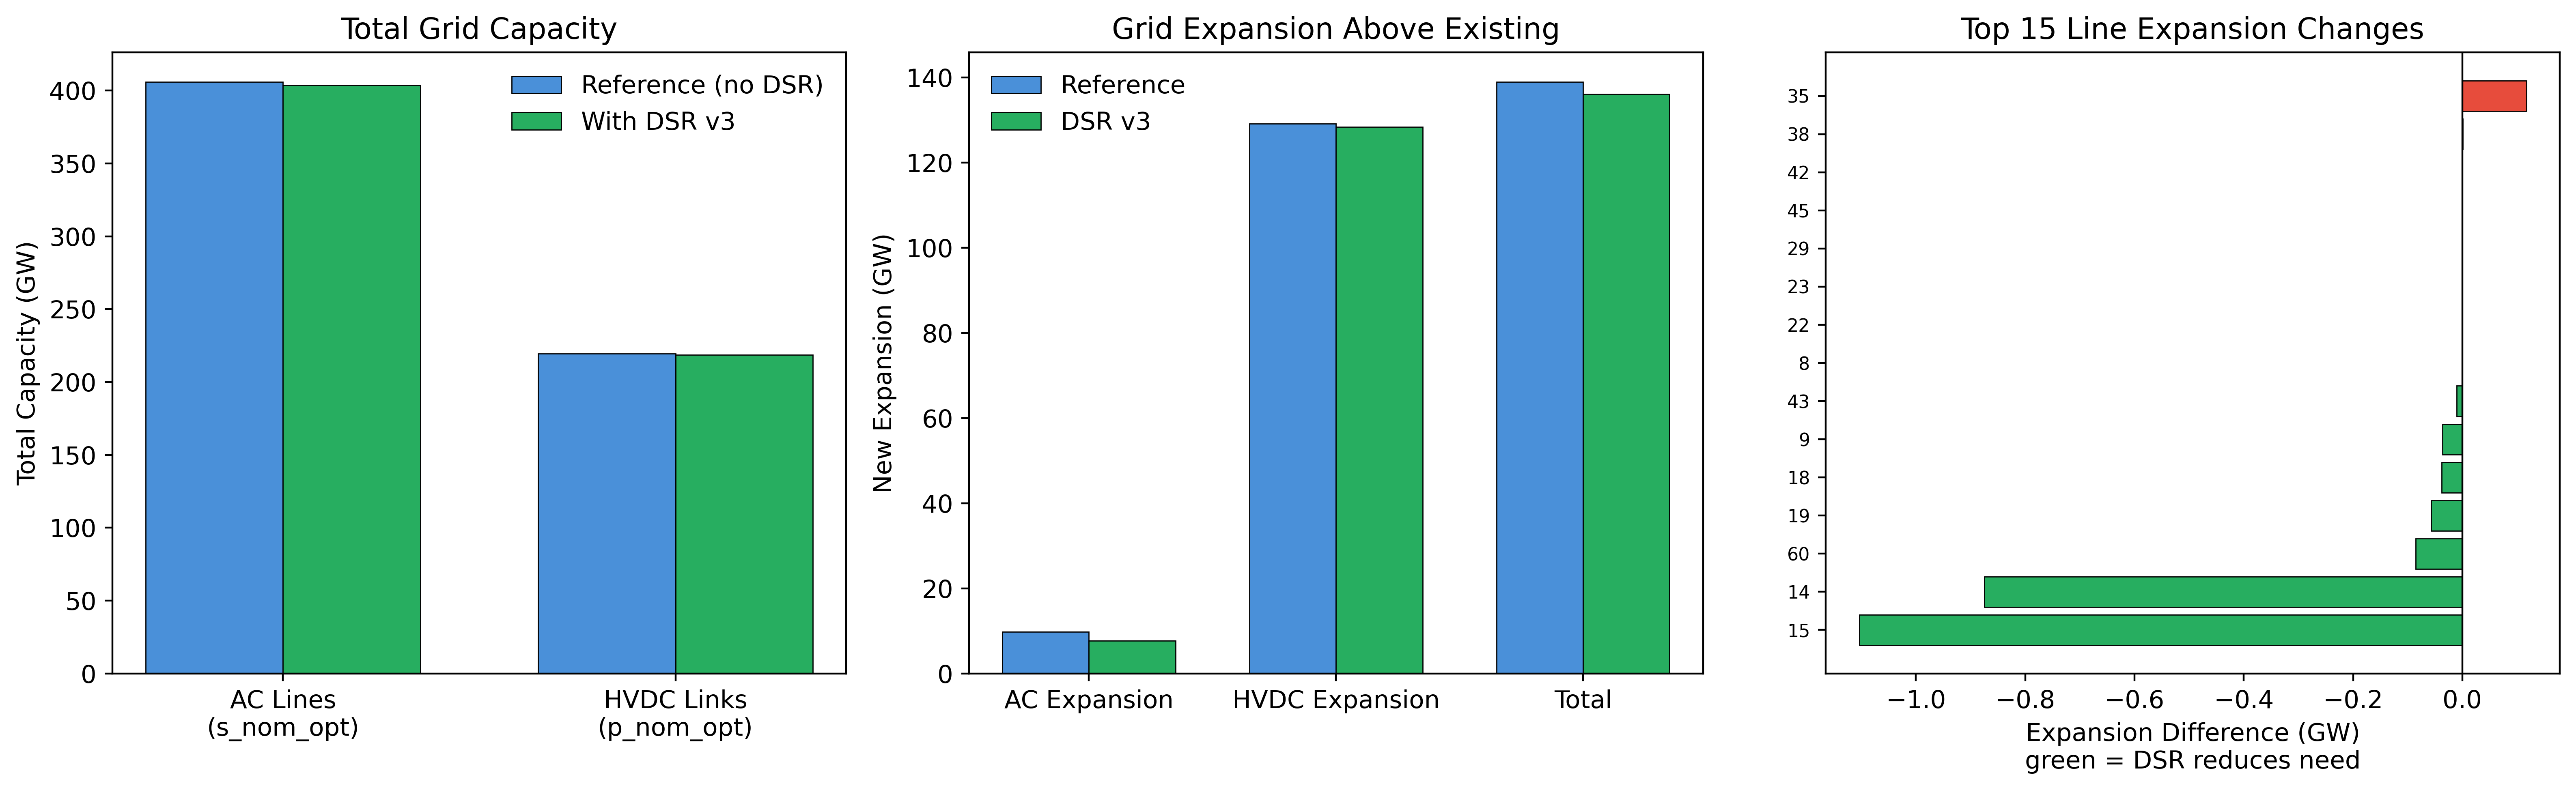

In [13]:
# ---- AC Lines ----
lines_ref = n_ref.lines.copy()
lines_dsr = n_dsr.lines.copy()

# Optimal capacity
total_s_nom_opt_ref = lines_ref.s_nom_opt.sum() / 1e3  # GW
total_s_nom_opt_dsr = lines_dsr.s_nom_opt.sum() / 1e3
# New capacity built (expansion above existing)
lines_ref['expansion'] = (lines_ref.s_nom_opt - lines_ref.s_nom).clip(lower=0)
lines_dsr['expansion'] = (lines_dsr.s_nom_opt - lines_dsr.s_nom).clip(lower=0)
total_exp_ref = lines_ref.expansion.sum() / 1e3
total_exp_dsr = lines_dsr.expansion.sum() / 1e3

print('=== AC Transmission Lines ===')
print(f'Total optimal capacity  - Reference: {total_s_nom_opt_ref:.1f} GW | DSR: {total_s_nom_opt_dsr:.1f} GW')
print(f'Total NEW expansion     - Reference: {total_exp_ref:.1f} GW | DSR: {total_exp_dsr:.1f} GW')
print(f'DSR impact on expansion: {(total_exp_dsr - total_exp_ref)/total_exp_ref*100:+.2f}%')

# ---- DC Links (HVDC, not DSR links) ----
dc_carriers = ['DC']
dc_ref = n_ref.links[n_ref.links.carrier.isin(dc_carriers)]
dc_dsr = n_dsr.links[n_dsr.links.carrier.isin(dc_carriers)]

total_dc_ref = dc_ref.p_nom_opt.sum() / 1e3
total_dc_dsr = dc_dsr.p_nom_opt.sum() / 1e3
dc_ref_exp = (dc_ref.p_nom_opt - dc_ref.p_nom).clip(lower=0).sum() / 1e3
dc_dsr_exp = (dc_dsr.p_nom_opt - dc_dsr.p_nom).clip(lower=0).sum() / 1e3

print(f'\n=== HVDC Links ===')
print(f'Total optimal capacity  - Reference: {total_dc_ref:.1f} GW | DSR: {total_dc_dsr:.1f} GW')
print(f'Total NEW expansion     - Reference: {dc_ref_exp:.1f} GW | DSR: {dc_dsr_exp:.1f} GW')
if dc_ref_exp > 0:
    print(f'DSR impact on expansion: {(dc_dsr_exp - dc_ref_exp)/dc_ref_exp*100:+.2f}%')

# ---- Combined ----
combined_ref = total_exp_ref + dc_ref_exp
combined_dsr = total_exp_dsr + dc_dsr_exp
print(f'\n=== Combined Grid Expansion (AC + HVDC) ===')
print(f'Reference: {combined_ref:.1f} GW | DSR: {combined_dsr:.1f} GW')
print(f'DSR impact: {(combined_dsr - combined_ref):.1f} GW ({(combined_dsr - combined_ref)/combined_ref*100:+.2f}%)')

# ---- PLOT: Grid expansion comparison ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Total capacity bar chart
ax = axes[0]
categories = ['AC Lines\n(s_nom_opt)', 'HVDC Links\n(p_nom_opt)']
ref_vals = [total_s_nom_opt_ref, total_dc_ref]
dsr_vals = [total_s_nom_opt_dsr, total_dc_dsr]
x = np.arange(len(categories))
w = 0.35
ax.bar(x - w/2, ref_vals, w, color='#4a90d9', label='Reference (no DSR)', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, dsr_vals, w, color='#27ae60', label='With DSR v3', edgecolor='black', linewidth=0.5)
ax.set_ylabel('Total Capacity (GW)')
ax.set_title('Total Grid Capacity')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# (b) New expansion only
ax = axes[1]
categories_exp = ['AC Expansion', 'HVDC Expansion', 'Total']
ref_exp = [total_exp_ref, dc_ref_exp, combined_ref]
dsr_exp = [total_exp_dsr, dc_dsr_exp, combined_dsr]
x = np.arange(len(categories_exp))
ax.bar(x - w/2, ref_exp, w, color='#4a90d9', label='Reference', edgecolor='black', linewidth=0.5)
ax.bar(x + w/2, dsr_exp, w, color='#27ae60', label='DSR v3', edgecolor='black', linewidth=0.5)
ax.set_ylabel('New Expansion (GW)')
ax.set_title('Grid Expansion Above Existing')
ax.set_xticks(x)
ax.set_xticklabels(categories_exp)
ax.legend()

# (c) Top 10 AC line expansion differences
common_lines = lines_ref.index.intersection(lines_dsr.index)
line_diff = (lines_dsr.loc[common_lines, 'expansion'] - lines_ref.loc[common_lines, 'expansion']) / 1e3  # GW
top_changes = line_diff.abs().nlargest(15)
top_diffs = line_diff.loc[top_changes.index].sort_values()
colors = ['#27ae60' if v < 0 else '#e74c3c' for v in top_diffs.values]

ax = axes[2]
# Shorten names for readability
short_names = [f'{n[:20]}...' if len(n) > 20 else n for n in top_diffs.index]
ax.barh(range(len(top_diffs)), top_diffs.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(top_diffs)))
ax.set_yticklabels(short_names, fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Expansion Difference (GW)\ngreen = DSR reduces need')
ax.set_title('Top 15 Line Expansion Changes')

plt.tight_layout()
plt.show()

## 9. Summary

In [14]:
# Summary table
dsr_stores = n_dsr.stores[n_dsr.stores.carrier == 'industry dsr']
ch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr charge']
dch_links = n_dsr.links[n_dsr.links.carrier == 'industry dsr discharge']

re_carriers = ['solar', 'onwind', 'offwind-ac', 'offwind-dc', 'offwind-float']
curt = {}
for label, n_ in [('Reference', n_ref), ('DSR v3', n_dsr)]:
    re = n_.generators[n_.generators.carrier.isin(re_carriers)]
    pot = (n_.generators_t.p_max_pu[re.index] * re.p_nom_opt).sum().sum()
    act = n_.generators_t.p[re.index].sum().sum()
    curt[label] = (pot - act) / 1e6

summary = pd.DataFrame({
    'Metric': [
        'System Cost (B EUR/year)',
        'Average LV Price (EUR/MWh)',
        'Renewable Curtailment (TWh)',
        'DSR Capacity Built (MWh)',
        'DSR Energy Shifted (TWh)',
        'DSR Investment (M EUR/year)',
        'System Cost Savings (B EUR/year)',
    ],
    'Reference (no DSR)': [
        f'{n_ref.objective/1e9:.2f}',
        f'{avg_ref:.2f}',
        f'{curt["Reference"]:.2f}',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
    ],
    'DSR v3': [
        f'{n_dsr.objective/1e9:.2f}',
        f'{avg_dsr:.2f}',
        f'{curt["DSR v3"]:.2f}',
        f'{dsr_stores.e_nom_opt.sum():.0f}',
        f'{n_dsr.links_t.p0[ch_links.index].sum().sum()/1e6:.2f}',
        f'{(dsr_stores.e_nom_opt * dsr_stores.capital_cost).sum()/1e6:.2f}',
        f'{(n_ref.objective - n_dsr.objective)/1e9:.2f}',
    ],
})

print('\n' + '='*70)
print('INDUSTRY DSR IMPACT SUMMARY')
print('='*70)
print(summary.to_string(index=False))
print('\nConclusion: DSR reduces system cost, lowers prices, and cuts curtailment.')
print('The optimizer rationally builds DSR where the arbitrage value exceeds costs.')


INDUSTRY DSR IMPACT SUMMARY
                          Metric Reference (no DSR) DSR v3
        System Cost (B EUR/year)             614.89 592.37
      Average LV Price (EUR/MWh)             102.56  99.83
     Renewable Curtailment (TWh)              25.51  24.54
        DSR Capacity Built (MWh)                N/A 296393
        DSR Energy Shifted (TWh)                N/A  26.21
     DSR Investment (M EUR/year)                N/A   0.89
System Cost Savings (B EUR/year)                N/A  22.52

Conclusion: DSR reduces system cost, lowers prices, and cuts curtailment.
The optimizer rationally builds DSR where the arbitrage value exceeds costs.


## Sectoral temporal profiles – example day

In this section we look at the **hourly temporal profile of industrial electricity demand** for a
single representative day, comparing two industry profiles (e.g. **Iron & steel industry** and
**Non-metallic Minerals**).

We use the pre-built files `industrial_electricity_demand_per_profile_temporal_base_s_37_2040.csv`
from the reference and high-flexibility runs, aggregate the demand over all nodes for the selected
profiles, and plot the resulting time series for one day.

This helps visualise how different industrial sectors contribute to intraday flexibility and how
their load shapes differ.

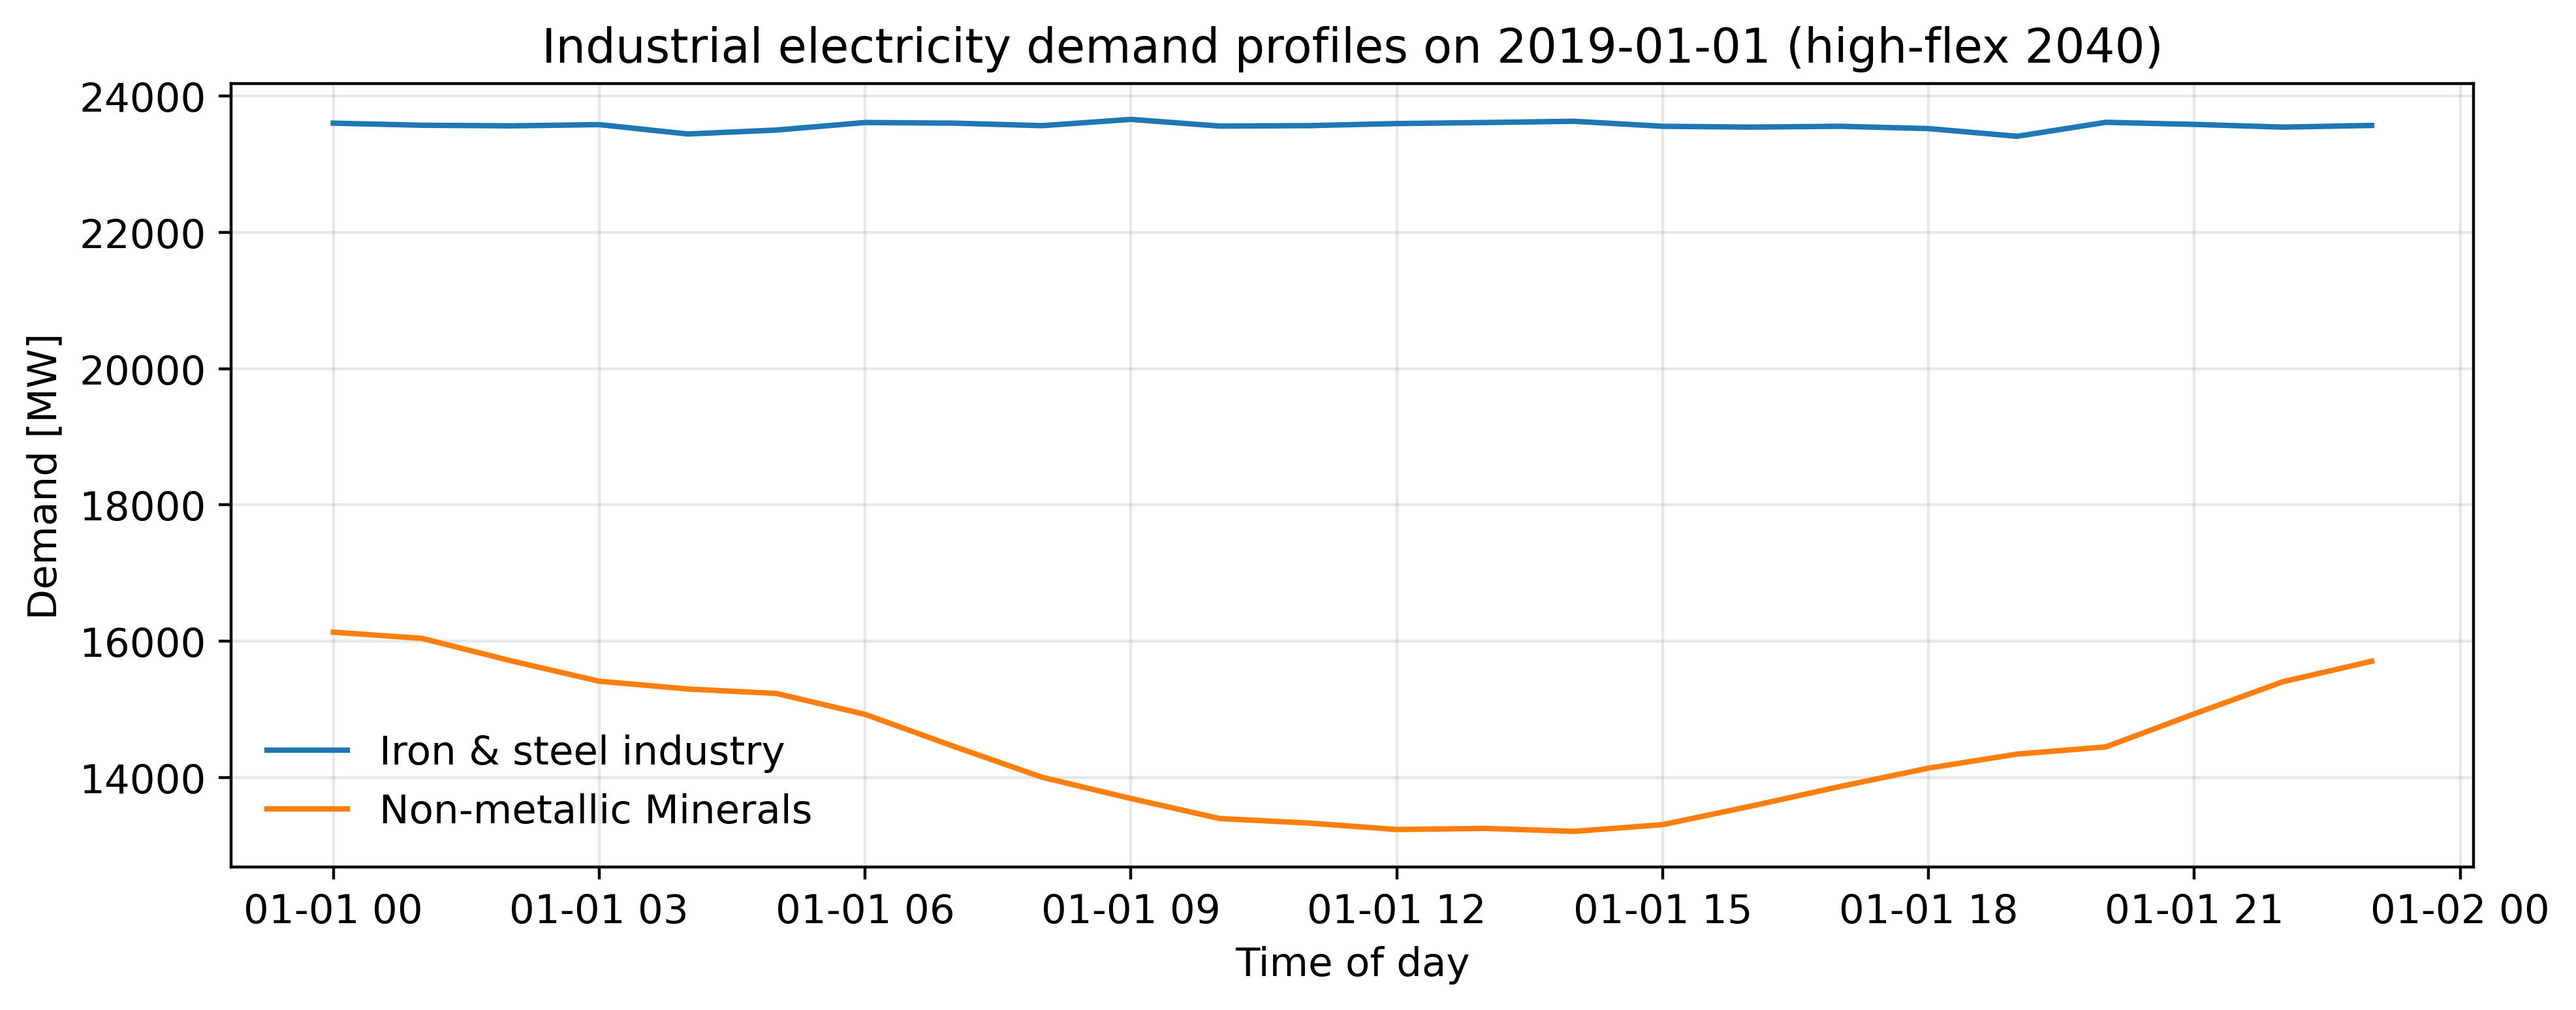

In [19]:
# Plot one-day temporal profiles for selected industrial sectors

import pandas as pd
import matplotlib.pyplot as plt

# Paths to per-profile industrial electricity demand (MW) for 2040
# Adjust clusters/year if you change scenario configuration
path_ref_profiles = "resources/2026-02/lowflex-2040-solar-cap-H2net-bio/industrial_electricity_demand_per_profile_temporal_base_s_37_2040.csv"
path_flex_profiles = "resources/2027-04-03/flex-2040-solar-cap-H2net-bio/industrial_electricity_demand_per_profile_temporal_base_s_37_2040.csv"

# Load high-flex run profiles (you can switch to ref_profiles if you prefer)
profiles = pd.read_csv(path_flex_profiles, index_col=0, parse_dates=True)

# Columns are of the form "<node>|<profile>"; aggregate over all nodes for each profile
profiles.columns = profiles.columns.str.split("|", n=1, expand=True)
profiles.columns.names = ["node", "profile"]

# Pick two example industry profiles (must match names in INDUSTRY_CATEGORY_TO_PROFILE)
profile_a = "Iron & steel industry"
profile_b = "Non-metallic Minerals"

if profile_a not in profiles.columns.get_level_values("profile"):
    raise ValueError(f"Profile '{profile_a}' not found in columns: {profiles.columns.get_level_values('profile').unique().tolist()}")
if profile_b not in profiles.columns.get_level_values("profile"):
    raise ValueError(f"Profile '{profile_b}' not found in columns: {profiles.columns.get_level_values('profile').unique().tolist()}")

series_a = profiles.xs(profile_a, axis=1, level="profile").sum(axis=1)
series_b = profiles.xs(profile_b, axis=1, level="profile").sum(axis=1)

# Select a representative day (first day in the time index)
first_day = series_a.index[0].normalize()
mask = (series_a.index.date == first_day.date())

day_a = series_a.loc[mask]
day_b = series_b.loc[mask]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(day_a.index, day_a, label=profile_a)
ax.plot(day_b.index, day_b, label=profile_b)

ax.set_title(f"Industrial electricity demand profiles on {first_day.date()} (high-flex 2040)")
ax.set_ylabel("Demand [MW]")
ax.set_xlabel("Time of day")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Industrial DSR in action – cement (Non-metallic Minerals)

This section shows the industrial Demand Side Response (DSR) working for the **cement sector**,
comparing the exogenous **FfE baseline profile** (what the model takes as input) against the
**optimised actual demand** (what the model decides to consume after DSR shifting).

The model contains process-level DSR stores for cement mills and raw mills
(`industry dsr Non-metallic Minerals Cement mills / Raw mills`).
These stores allow the optimiser to shift cement milling demand in time:

- **Store charges (p > 0)**: mills run *faster* than baseline — production **preponed**
- **Store discharges (p < 0)**: mills run *slower* than baseline — production **postponed**
- **State of charge (SOC)**: how much production has been "borrowed" from or "lent" to future hours

The three panels show a winter week (January 2040):
1. **FfE baseline** (dashed) vs optimised demand for low-flex (10%) and high-flex (38%)
2. **DSR store power** — the shift applied each hour
3. **DSR store SOC** — cumulative shifted energy (orange = pre-shifted, purple = deferred)


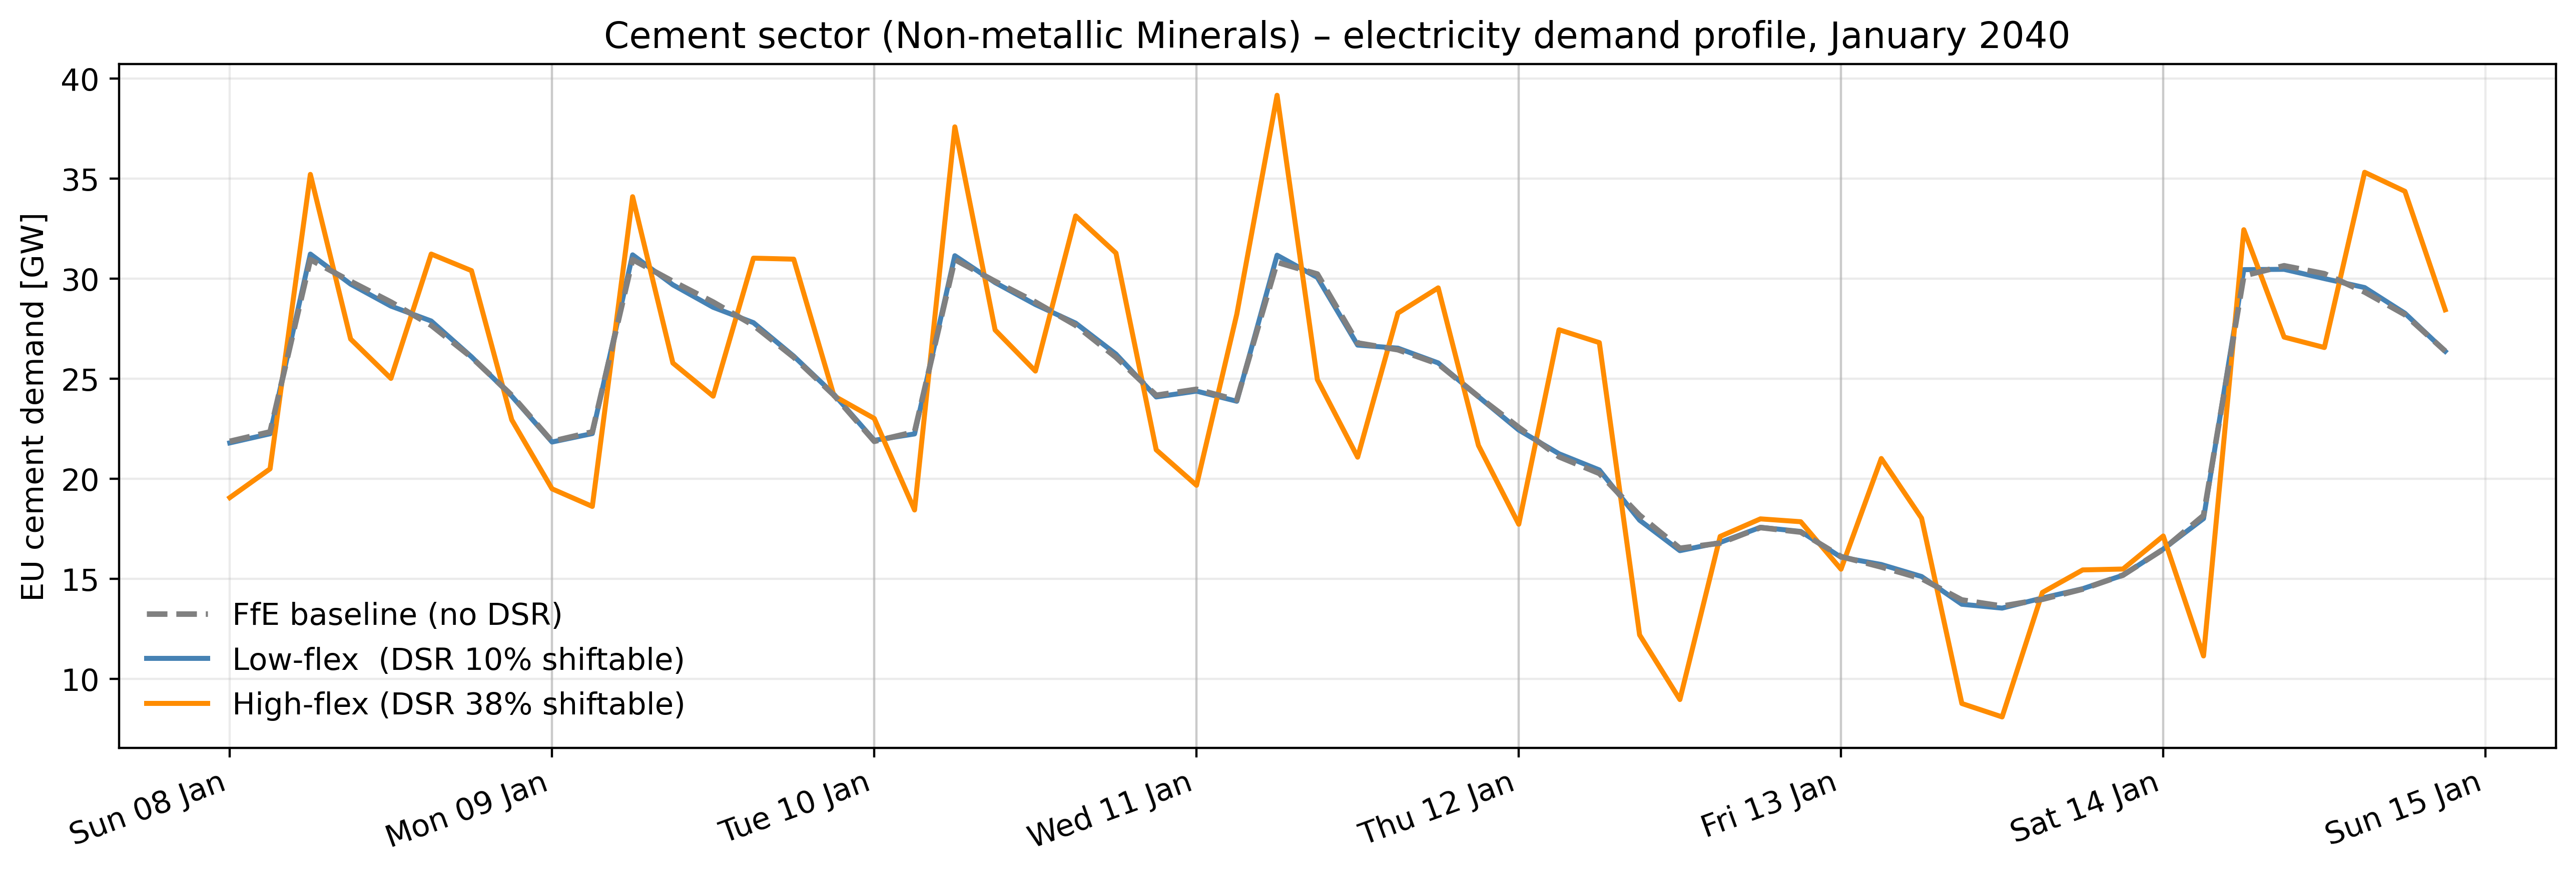

In [16]:
# Cement (Non-metallic Minerals) electricity demand profile: FfE baseline vs DSR scenarios
#
# The FfE profile is the exogenous hourly shape assigned to cement demand.
# Industrial DSR stores allow the optimiser to shift this demand in time.
# Here we compare three curves over a winter week:
#   - FfE baseline  : the original profile (no flexibility)
#   - Low-flex run  : after optimisation with 10% shiftable fraction
#   - High-flex run : after optimisation with 38% shiftable fraction

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- FfE baseline (Non-metallic Minerals, EU total, resampled to 3h) ---
path_profiles = "resources/2027-04-03/flex-2040-solar-cap-H2net-bio/industrial_electricity_demand_per_profile_temporal_base_s_37_2040.csv"
prof = pd.read_csv(path_profiles, index_col=0, parse_dates=True)
prof.columns = prof.columns.str.split("|", n=1, expand=True)
prof.columns.names = ["node", "profile"]
ffe_1h = prof.xs("Non-metallic Minerals", axis=1, level="profile").sum(axis=1) / 1e3  # GW
ffe_3h = ffe_1h.resample("3h").mean().reindex(n_dsr.snapshots)

# --- DSR store p_t for cement (all nodes, EU total) ---
cement_p_ref = n_ref.stores_t.p.filter(regex="industry dsr Non-metallic Minerals").sum(axis=1) / 1e3
cement_p_dsr = n_dsr.stores_t.p.filter(regex="industry dsr Non-metallic Minerals").sum(axis=1) / 1e3

# actual demand = FfE + DSR shift (positive = pre-poning, negative = postponing)
actual_ref = ffe_3h + cement_p_ref
actual_dsr = ffe_3h + cement_p_dsr

# --- select a winter week (week 2 of January) ---
week_start = n_dsr.snapshots[0] + pd.Timedelta(days=7)
week_end   = week_start + pd.Timedelta(days=7)
t_slice    = slice(week_start, week_end - pd.Timedelta(hours=1))

# shift year to 2040 for display
year_offset = pd.DateOffset(years=2040 - n_dsr.snapshots[0].year)
plot_idx    = ffe_3h[t_slice].index + year_offset
wstart_lbl  = week_start + year_offset

# --- plot ---
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(plot_idx, ffe_3h[t_slice],     color="gray",       linewidth=2,   linestyle="--",
        label="FfE baseline (no DSR)", zorder=3)
ax.plot(plot_idx, actual_ref[t_slice], color="steelblue",  linewidth=1.8,
        label="Low-flex  (DSR 10% shiftable)")
ax.plot(plot_idx, actual_dsr[t_slice], color="darkorange", linewidth=1.8,
        label="High-flex (DSR 38% shiftable)")

# day separators
for d in range(1, 7):
    ax.axvline(wstart_lbl + pd.Timedelta(days=d), color="lightgray", linestyle="-", linewidth=0.8, zorder=0)

ax.set_title("Cement sector (Non-metallic Minerals) – electricity demand profile, January 2040")
ax.set_ylabel("EU cement demand [GW]")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha="right")
ax.legend()
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


## DSR flexibility in action – winter week comparison

Here we look directly at the **solved network results** to see the DSR store actually operating.

The DSM model in PyPSA-Eur represents the building thermal mass as a short-term heat "battery":

| Store state | Physical meaning |
|---|---|
| **Charging** (p > 0) | Building is *overheated* ahead of time — demand is **preponed** |
| **Discharging** (p < 0) | Building coasts on stored heat — demand is **postponed** |
| **State of charge (SOC)** | How much energy is currently "banked" in the thermal mass |

We compare the **low-flex** run (10% shiftable fraction) against the **high-flex** run (38% shiftable
fraction), aggregated over all EU urban central heat nodes, for a representative winter week.

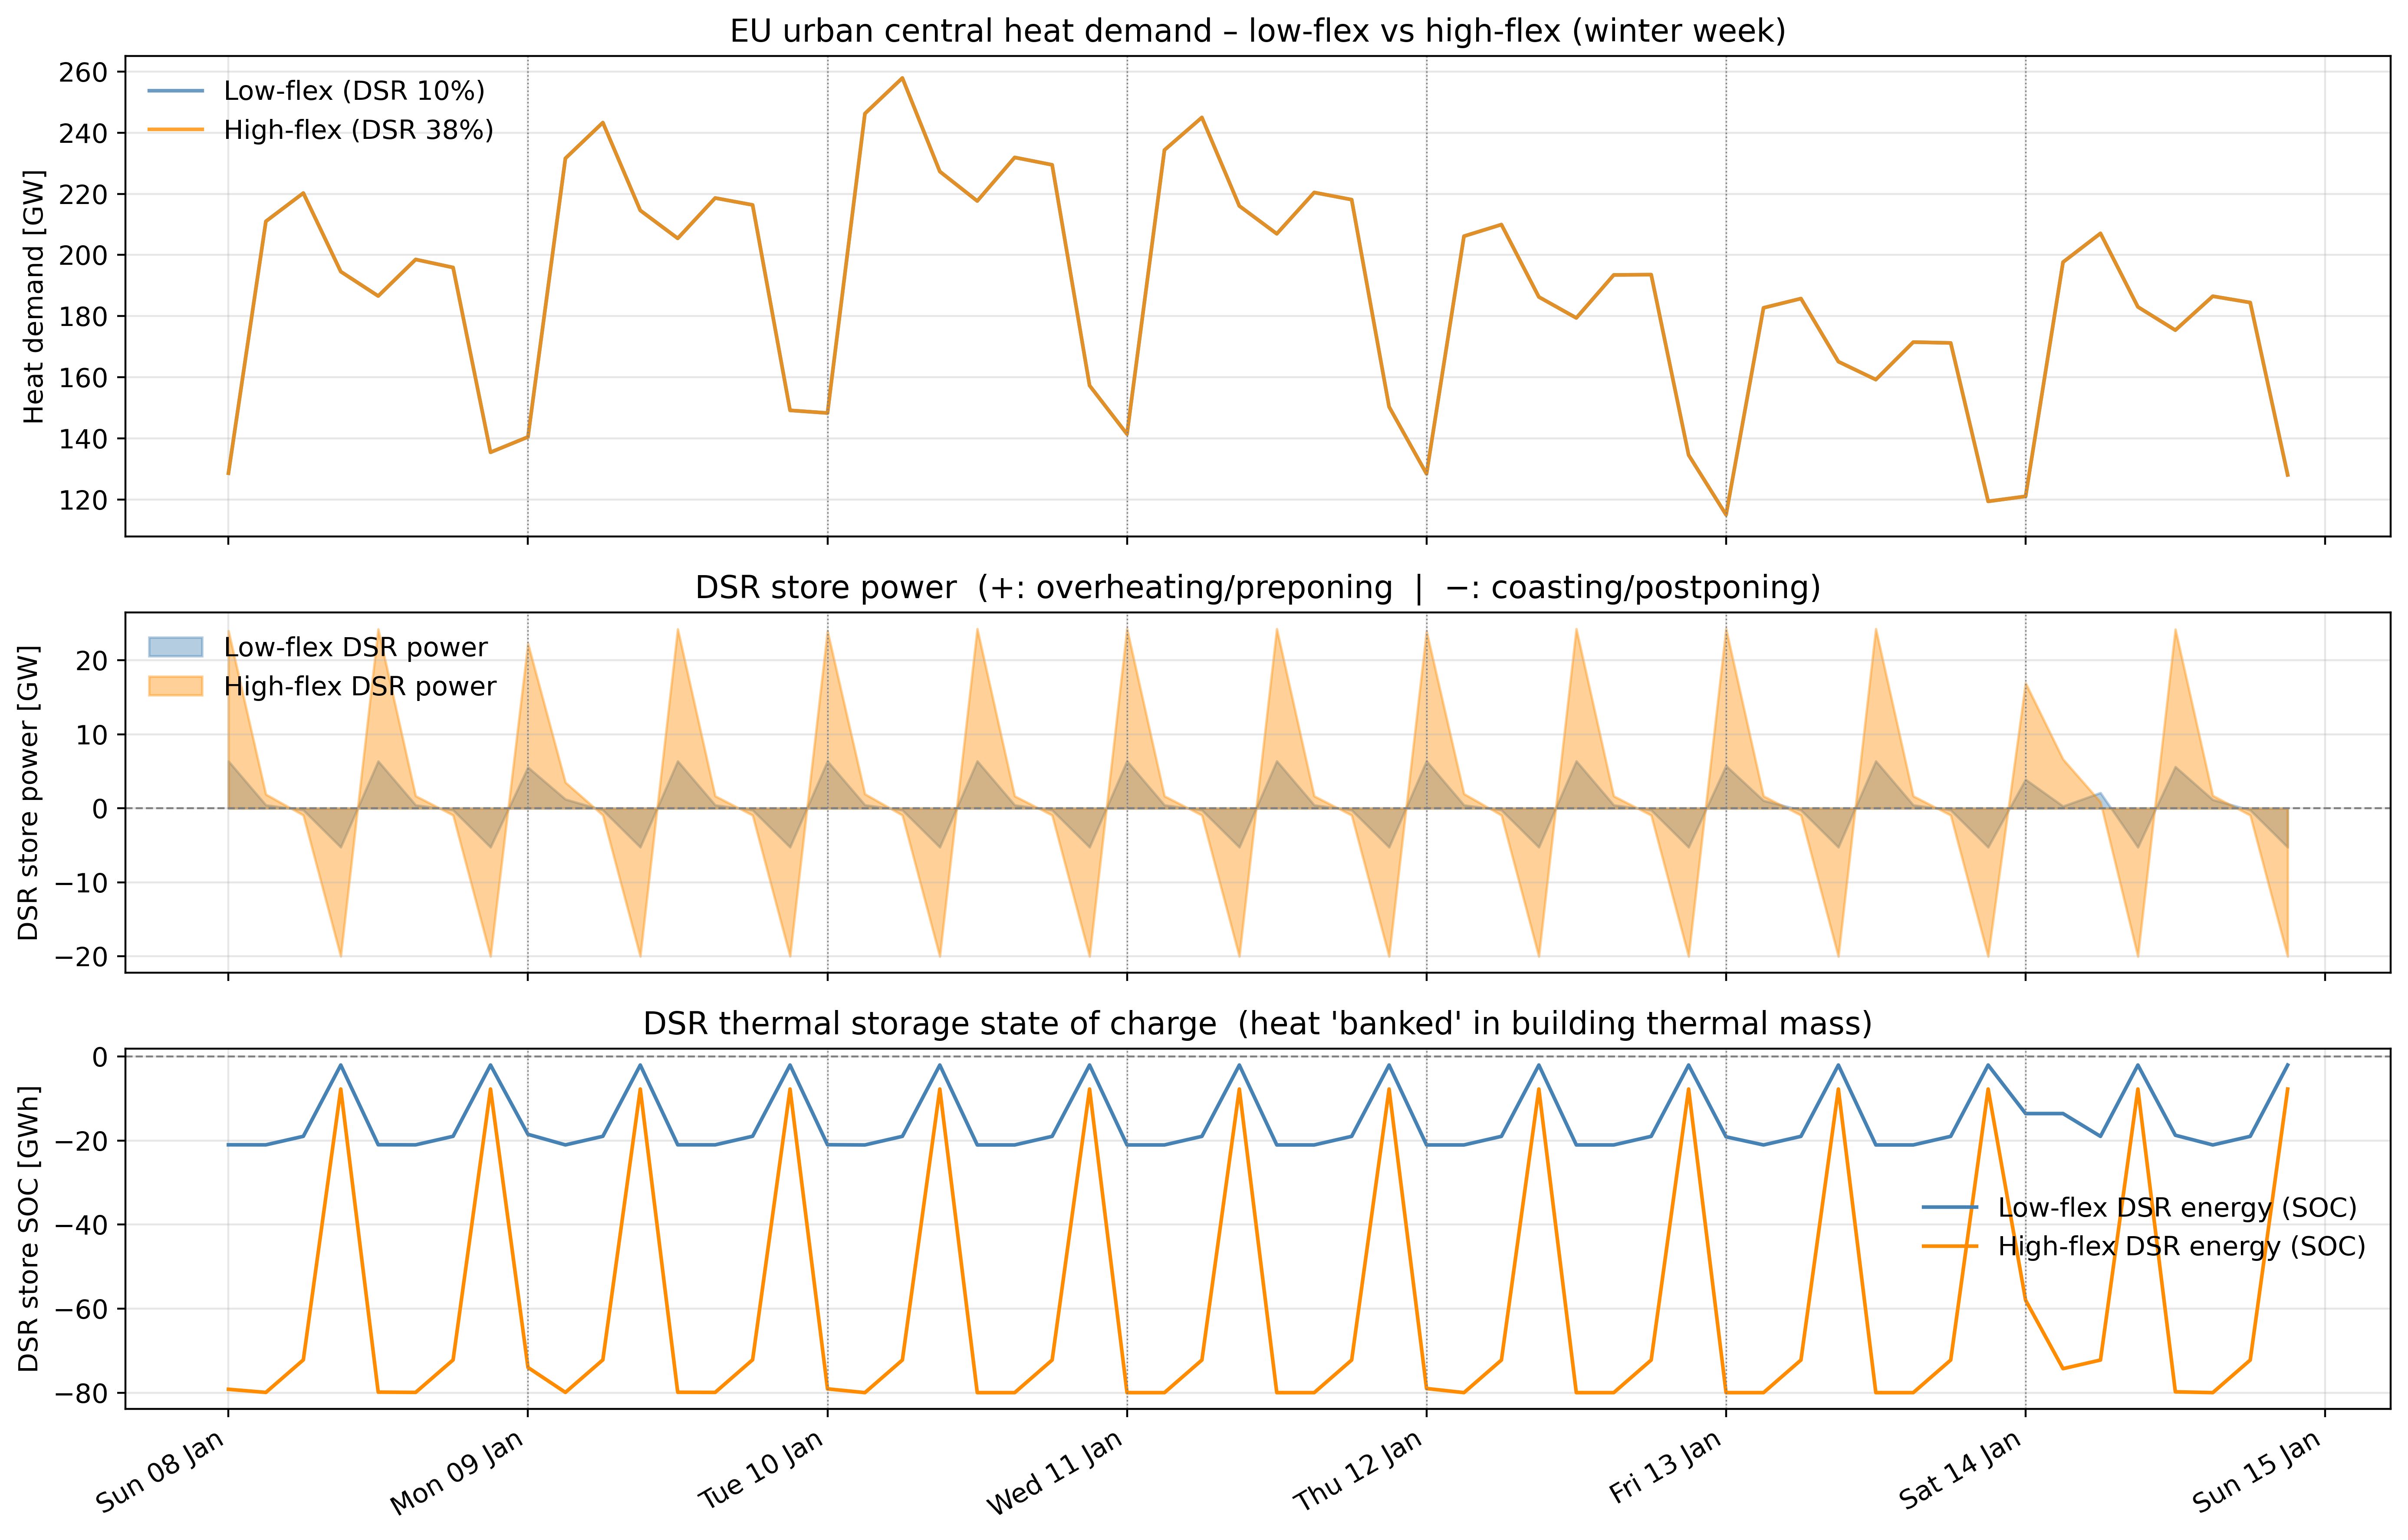


Max DSR store SOC across week:  low-flex = 21 GWh  |  high-flex = 80 GWh
Max DSR store power across week: low-flex = 6 GW  |  high-flex = 24 GW


In [17]:
# DSR flexibility in action: compare heat demand + DSR store SOC for low-flex vs high-flex
#
# The DSR store models the building thermal mass as a short-term heat "battery":
#   - Store charges (p > 0) → building is overheated ahead of time (demand preponed)
#   - Store discharges (p < 0) → building coasts down using stored heat (demand postponed)
#   - State of charge (e_t) shows how much energy is currently "banked" in the thermal mass
#
# We aggregate all urban-central-heat DSM stores across all nodes (EU total) to see
# the system-level effect of the two different flexibility levels (10% vs 38% shiftable).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -- select a winter week to plot (week 2 of January: days 7-14) --
week_start = n_ref.snapshots[0] + pd.Timedelta(days=7)
week_end   = week_start + pd.Timedelta(days=7)
t_slice    = slice(week_start, week_end - pd.Timedelta(hours=1))

# -- aggregate EU-wide urban central heat loads (GW) --
uch_loads_ref = n_ref.loads_t.p_set.filter(regex="urban central heat$").sum(axis=1) / 1e3
uch_loads_dsr = n_dsr.loads_t.p_set.filter(regex="urban central heat$").sum(axis=1) / 1e3

# -- aggregate EU-wide DSM store power and state of charge (GW / GWh) --
dsm_p_ref   = n_ref.stores_t.p.filter(regex="urban central heat dsm$").sum(axis=1) / 1e3
dsm_e_ref   = n_ref.stores_t.e.filter(regex="urban central heat dsm$").sum(axis=1) / 1e3
dsm_p_dsr   = n_dsr.stores_t.p.filter(regex="urban central heat dsm$").sum(axis=1) / 1e3
dsm_e_dsr   = n_dsr.stores_t.e.filter(regex="urban central heat dsm$").sum(axis=1) / 1e3

# Slice to selected week
uch_ref_w  = uch_loads_ref[t_slice]
uch_dsr_w  = uch_loads_dsr[t_slice]
dsm_p_r_w  = dsm_p_ref[t_slice]
dsm_p_d_w  = dsm_p_dsr[t_slice]
dsm_e_r_w  = dsm_e_ref[t_slice]
dsm_e_d_w  = dsm_e_dsr[t_slice]

# Shift timestamps from the internal weather year to 2040 for display
weather_year = n_ref.snapshots[0].year
year_offset  = pd.DateOffset(years=2040 - weather_year)
plot_idx     = uch_ref_w.index + year_offset
week_start_label = week_start + year_offset

# -- plot: 3 rows, shared x-axis --
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1.5, 1.5]})

# Row 1: urban central heat load comparison
ax = axes[0]
ax.plot(plot_idx, uch_ref_w, color="steelblue", linewidth=1.5,
        label="Low-flex (DSR 10%)", alpha=0.8)
ax.plot(plot_idx, uch_dsr_w, color="darkorange", linewidth=1.5,
        label="High-flex (DSR 38%)", alpha=0.8)
ax.set_ylabel("Heat demand [GW]")
ax.set_title("EU urban central heat demand – low-flex vs high-flex (winter week)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 2: DSM store power (positive = charging = preheating, negative = discharging = postponing)
ax = axes[1]
ax.fill_between(plot_idx, dsm_p_r_w, alpha=0.4, color="steelblue",
                label="Low-flex DSR power")
ax.fill_between(plot_idx, dsm_p_d_w, alpha=0.4, color="darkorange",
                label="High-flex DSR power")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("DSR store power [GW]")
ax.set_title("DSR store power  (+: overheating/preponing  |  −: coasting/postponing)")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 3: DSM store state of energy (thermal bank)
ax = axes[2]
ax.plot(plot_idx, dsm_e_r_w, color="steelblue", linewidth=1.5,
        label="Low-flex DSR energy (SOC)")
ax.plot(plot_idx, dsm_e_d_w, color="darkorange", linewidth=1.5,
        label="High-flex DSR energy (SOC)")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("DSR store SOC [GWh]")
ax.set_title("DSR thermal storage state of charge  (heat 'banked' in building thermal mass)")
ax.legend()
ax.grid(True, alpha=0.3)

# x-axis formatting: show day labels
axes[2].xaxis.set_major_locator(mdates.DayLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha="right")

# vertical day separators
for ax in axes:
    for d in range(1, 7):
        ax.axvline(week_start_label + pd.Timedelta(days=d), color="gray", linestyle=":", linewidth=0.6)

plt.tight_layout()
plt.show()

print(f"\nMax DSR store SOC across week:  low-flex = {dsm_e_r_w.abs().max():.0f} GWh  |  high-flex = {dsm_e_d_w.abs().max():.0f} GWh")
print(f"Max DSR store power across week: low-flex = {dsm_p_r_w.abs().max():.0f} GW  |  high-flex = {dsm_p_d_w.abs().max():.0f} GW")

In [18]:
# Sanity check: industrial electricity totals (flat vs temporal)

import pandas as pd

# Paths for high-flex 2040 run
path_annual = "resources/2027-04-03/flex-2040-solar-cap-H2net-bio/industrial_energy_demand_base_s_37_2040.csv"
path_temporal = "resources/2027-04-03/flex-2040-solar-cap-H2net-bio/industrial_electricity_demand_temporal_base_s_37_2040.csv"

annual = pd.read_csv(path_annual, index_col=0)
flat_TWh = annual["electricity"].sum()

prof = pd.read_csv(path_temporal, index_col=0, parse_dates=True)
# MW * h summed over all hours and nodes, /1e6 → TWh
temporal_TWh = prof.sum().sum() / 1e6

print(f"Flat industrial electricity demand (TWh/a):     {flat_TWh:.2f}")
print(f"Temporal industrial electricity demand (TWh/a): {temporal_TWh:.2f}")

Flat industrial electricity demand (TWh/a):     1540.95
Temporal industrial electricity demand (TWh/a): 1540.95
